Connected to .venv (Python 3.10.12)

In [ ]:
# IMPORTS
import os
import glob
import random
import logging
from typing import List, Tuple, Optional
import time
import copy

import numpy as np
import mne
import wfdb
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import expit
from sklearn.metrics import accuracy_score


import torch.ao.quantization as tq
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping, get_default_qat_qconfig, fuse_modules
from torch.ao.quantization.quantize_fx import prepare_fx, prepare_qat_fx, convert_fx


warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="TypedStorage is deprecated")
warnings.filterwarnings("ignore", message="Please use quant_min and quant_max to specify the range for observers")
warnings.filterwarnings("ignore", message="must run observer before calling calculate_qparams")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

 ### CONFIGURATION
 ---

In [ ]:
# Path to the root folder containing CHB-MIT patient directories (chb01, chb02, ...)
#DATA_ROOT = "./dataset/chb-mit-1.0.0"
# DATA_ROOT = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"
DATA_ROOT = "chb-mit-scalp-eeg-database-1.0.0"

# Optional: folder to cache preprocessed arrays (will be created if it doesn't exist)
# PROCESSED_DIR = "/kaggle/working/processed_chb_mit"
PROCESSED_DIR = "processed_chb_mit"

# EEG bipolar channels to use (18 channels)
CHANNELS = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
    "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
    "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
    "FP2-F8", "F8-T8", "T8-P8-1", "P8-O2",
    "FZ-CZ", "CZ-PZ",
]
ORIGINAL_CHANNELS = list(CHANNELS)

# Windowing parameters
TIME_WINDOW = 8.0   # seconds per segment
TIME_STEP = 4.0     # seconds between segment starts

# Target sampling frequency after downsampling (CHB-MIT is originally 256 Hz)
TARGET_FS = 128.0

# Non-seizure sampling probability per candidate window (imbalance handling)
P_NON_SEIZURE = 0.01

# Train / test split at patient level
TRAIN_RATIO = 0.8

# Within-training set: validation split
VAL_RATIO = 0.3

# Random seeds for reproducibility
SEED = 2025

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 256
EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20

 ### SETUP & UTILITIES
 ---

In [ ]:
def setup_logging():
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    logging.basicConfig(
        filename=os.path.join(PROCESSED_DIR, "preprocessing.log"),
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
    )
    logging.getLogger().addHandler(logging.StreamHandler())


def set_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # extra reproducibility settings (optional but recommended)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def list_patient_dirs(root: str) -> List[str]:
    """Return sorted list of patient directory names (e.g. ['chb01', 'chb02', ...])."""
    dirs = sorted(
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d)) and d.lower().startswith("chb")
    )
    return dirs


def split_patients(patients: List[str], train_ratio: float = TRAIN_RATIO) -> Tuple[List[str], List[str]]:
    """Split patient IDs into train and test sets."""
    n_train = int(round(train_ratio * len(patients)))
    train = sorted(random.sample(patients, n_train))
    test = sorted([p for p in patients if p not in train])
    return train, test


def collect_edf_files(root: str, patient_ids: List[str]) -> List[str]:
    """Collect all .edf files for given patient IDs."""
    files = []
    for pid in patient_ids:
        pattern = os.path.join(root, pid, "*.edf")
        files.extend(sorted(glob.glob(pattern)))
    return files

def processed_files_exist(processed_dir):
    required = [
        "X_train.npy", "y_train.npy",
        "X_val.npy", "y_val.npy",
        "X_test.npy", "y_test.npy",
    ]
    return all(os.path.exists(os.path.join(processed_dir, f)) for f in required)

 # Stage 1: Data Processing
 ---
 #### 1.1 SEIZURE ANNOTATIONS

In [ ]:
def load_seizure_mask(edf_path: str, n_samples: int, fs: float) -> np.ndarray:
    """
    Load seizure annotations for a given EDF file and return a binary mask
    of shape (n_samples,), where 1 indicates seizure.

    This assumes there is an annotation file with extension '.seizures'
    that WFDB can read via rdann.
    """
    mask = np.zeros(n_samples, dtype=np.int8)

    #record_base = os.path.splitext(edf_path)[0]  # includes path, without .edf
    record_base = edf_path
    ann_path = record_base + ".seizures"
    if not os.path.exists(ann_path):
        # No annotation file; treat as all non-seizure
        return mask

    try:
        # WFDB expects the "record name" without extension; can include path
        ann = wfdb.rdann(record_base, "seizures")
    except Exception as e:
        logging.warning(f"Failed to read annotation for {edf_path}: {e}")
        return mask

    # Typical assumption: ann.sample[0], ann.sample[1] are start/end of seizure 1, etc.
    samples = ann.sample
    if len(samples) < 2:
        return mask

    # Pair successive samples as start/end
    for start, end in zip(samples[0::2], samples[1::2]):
        start = max(0, int(start))
        end = min(n_samples, int(end))
        if end > start:
            mask[start:end] = 1

    return mask

 ---
 #### 1.2 PER-FILE WINDOWING

In [ ]:
def process_file_to_windows(
    edf_path: str,
    channels: List[str],
    time_window: float,
    time_step: float,
    target_fs: float,
    p_non_seizure: float
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Read one EDF file, extract sliding windows for the specified channels,
    and return:
        segments: (N_windows_selected, n_channels, n_time_samples)
        labels:   (N_windows_selected,) bool (True = seizure)

    Returns (None, None) if channels are not all present or no windows selected.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    except Exception as e:
        logging.warning(f"Failed to read {edf_path}: {e}")
        return None, None

    # Check channel availability
    available = set(raw.ch_names)
    if not all(ch in available for ch in channels):
        logging.info(f"Skipping {edf_path}: required channels missing.")
        return None, None

    raw.pick(channels)
    fs = float(raw.info["sfreq"])
    data = raw.get_data() * 1e6  # convert to microvolts
    n_channels, n_samples = data.shape

    # Build sample-level seizure mask (based on original sampling rate)
    sz_mask = load_seizure_mask(edf_path, n_samples, fs)

    # Downsample to target_fs by simple decimation (integer factor)
    if fs != target_fs:
        factor = int(round(fs / target_fs))
        if factor <= 0:
            raise ValueError(f"Invalid downsampling factor from fs={fs} to {target_fs}")
        data = data[:, ::factor]
        sz_mask = sz_mask[::factor]
        fs = fs / factor
        n_channels, n_samples = data.shape

    # Convert seconds to samples
    win_len = int(round(time_window * fs))
    step = int(round(time_step * fs))

    if n_samples < win_len:
        return None, None

    # Number of windows
    n_windows = 1 + (n_samples - win_len) // step
    if n_windows <= 0:
        return None, None

    # Compute seizure ratio for each window and keep segments in memory
    segs = []
    ratios = []

    for i in range(n_windows):
        start = i * step
        end = start + win_len
        seg = data[:, start:end]
        # Safety check for shape
        if seg.shape[1] != win_len:
            continue
        segs.append(seg)

        win_mask = sz_mask[start:end]
        ratio = win_mask.mean() if len(win_mask) > 0 else 0.0
        ratios.append(ratio)

    segs = np.stack(segs, axis=0)  # (n_windows, n_channels, win_len)
    ratios = np.array(ratios)

    # Select seizure and a subset of non-seizure windows
    idx_pos = np.where(ratios > 0.0)[0]
    idx_neg = np.where(ratios == 0.0)[0]

    selected_indices = []

    if len(idx_pos) > 0:
        selected_indices.append(idx_pos)

    if len(idx_neg) > 0 and p_non_seizure > 0.0:
        n_neg = int(round(p_non_seizure * len(idx_neg)))
        n_neg = max(0, min(n_neg, len(idx_neg)))
        if n_neg > 0:
            chosen_neg = np.random.choice(idx_neg, size=n_neg, replace=False)
            selected_indices.append(chosen_neg)

    if not selected_indices:
        return None, None

    selected_indices = np.concatenate(selected_indices)
    np.random.shuffle(selected_indices)

    segs = segs[selected_indices]
    labels = ratios[selected_indices] > 0.0  # bool: seizure if any seizure in window

    return segs, labels

 ---
  #### 1.3 DATASET BUILDING

In [ ]:
def build_dataset_from_files(files: List[str]) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Build dataset (segments, labels) from a list of EDF files.

    Returns:
        X: (N_segments, n_channels, n_time_samples)
        y: (N_segments,) bool
        fs: target sampling frequency used
    """
    all_segments = []
    all_labels = []

    for idx, fpath in enumerate(files):
        logging.info(f"[{idx + 1}/{len(files)}] Processing {fpath}")
        segs, labels = process_file_to_windows(
            fpath,
            channels=CHANNELS,
            time_window=TIME_WINDOW,
            time_step=TIME_STEP,
            target_fs=TARGET_FS,
            p_non_seizure=P_NON_SEIZURE
        )
        if segs is None:
            continue

        all_segments.append(segs)
        all_labels.append(labels)

    if not all_segments:
        raise RuntimeError("No segments were extracted from the provided files.")

    X = np.concatenate(all_segments, axis=0)
    y = np.concatenate(all_labels, axis=0)

    logging.info(f"Built dataset: X.shape={X.shape}, y.shape={y.shape}, "
                f"seizure_ratio={y.mean():.4f}")

    return X, y.astype(bool), TARGET_FS

 # Stage 2: Baseline creation

 #### 2.1. MODEL DEFINITION
 ---

In [ ]:
class EEGCNN(nn.Module):
    """
    2D CNN for EEG windows.

    Expects input of shape: (batch_size, 1, n_channels, n_time)
    Returns raw logits of shape: (batch_size, 1)
    """

    def __init__(self, in_channels):
        super().__init__()
        
        # 1D Convolutional Blocks
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv5 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.conv6 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool1d(2)
        
        # Classification Head
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1) # Final logic (binary)

    def forward(self, x):
        # x: (B, C, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool3(x)
        
        # Global Average Pooling
        x = self.global_pool(x).squeeze(-1) # (B, 256)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # (B, 1)
        
        return x.squeeze(1)

 ### 2.2. TRAINING & EVALUATION
 ---

In [ ]:
def train_and_evaluate(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray
):
    """
    Train the CNN (PyTorch) and evaluate on validation and test sets.
    Prints Keras-style logs and records training curves.
    Assumes EEGCNN.forward returns logits of shape (B,)
    and y_* are 0/1 arrays.
    """

    # ---- prepare tensors & loaders ----
    X_train_t = torch.from_numpy(X_train).float()  # (N,C,T)
    X_val_t   = torch.from_numpy(X_val).float()
    X_test_t  = torch.from_numpy(X_test).float()

    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    y_val_t   = torch.from_numpy(y_val.astype(np.float32))
    y_test_t  = torch.from_numpy(y_test.astype(np.float32))

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # ---- model, loss, optimizer, scheduler ----
    model = EEGCNN(in_channels=len(CHANNELS)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # history containers
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    lrs = []

    # ---- training loop ----
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for step, (xb, yb) in enumerate(train_loader, start=1):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)                  # (B,)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            # accuracy
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

        train_loss = running_loss / total
        train_acc = correct / total

        # ----- VALIDATION -----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                val_running_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_total += yb.numel()

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # ---- scheduler + history ----
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lrs.append(current_lr)

        epoch_time = time.time() - epoch_start
        steps_per_epoch = len(train_loader)
        ms_per_step = (epoch_time / steps_per_epoch) * 1000

        # Keras-style line
        print(f"{epoch}/{EPOCHS} - {epoch_time:.0f}s - {ms_per_step:.0f}ms/step "
                f"- accuracy: {train_acc:.4f} - loss: {train_loss:.4f} "
                f"- val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f} "
                f"- lr: {current_lr:.2e}")

        # ---- early stopping ----
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- evaluation helper ----
    def eval_on_loader(loader):
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE)
                logits = model(xb)              # (B,)
                probs = torch.sigmoid(logits)   # (B,)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        preds = (all_probs > 0.5).astype(int)
        return all_labels, all_probs, preds

    # ---- validation metrics ----
    y_val_true, y_val_probs, y_val_pred = eval_on_loader(val_loader)
    print("=== Validation report (threshold=0.5) ===")
    print(classification_report(y_val_true, y_val_pred, digits=4))
    try:
        val_auc = roc_auc_score(y_val_true, y_val_probs)
        print(f"Validation ROC AUC: {val_auc:.4f}")
    except ValueError:
        print("Validation ROC AUC: not defined (only one class present).")

    # ---- test metrics ----
    y_test_true, y_test_probs, y_test_pred = eval_on_loader(test_loader)
    print("=== Test report (threshold=0.5) ===")
    print(classification_report(y_test_true, y_test_pred, digits=4))
    try:
        test_auc = roc_auc_score(y_test_true, y_test_probs)
        print(f"Test ROC AUC: {test_auc:.4f}")
    except ValueError:
        print("Test ROC AUC: not defined (only one class present).")

    # ---- PLOTS: training curves ----
    epochs_range = range(1, len(train_losses) + 1)

    # Loss curves
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_losses, label="Train loss")
    plt.plot(epochs_range, val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy curves (optional but useful)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_accs, label="Train accuracy")
    plt.plot(epochs_range, val_accs, label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training / validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LR curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning rate schedule")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "lr": lrs,
    }

    return model, history

  ### 2.3. MAIN PIPELINE
  ---

In [ ]:
# 0. config & setup
setup_logging()
set_random_seeds(SEED)

def _save_state_dict_get_size_mb(state_dict, path):
    torch.save(state_dict, path)
    size_mb = os.path.getsize(path) / (1024.0 * 1024.0)
    return size_mb


def _infer_conv_weight_dim(model: nn.Module) -> Optional[int]:
    """
    Inspect the first convolution-like module and return its weight.dim() (3 for Conv1d, 4 for Conv2d).
    Returns None if no convolutional layers are found.
    """
    conv2d_types = [
        nn.Conv2d,
        getattr(torch.nn.quantized, "Conv2d", None),
        getattr(torch.ao.nn.quantized, "Conv2d", None),
    ]
    # Some FX converted models use intrinsic fused conv+relu types
    for mod_path in [
        "torch.ao.nn.intrinsic.quantized",
        "torch.ao.nn.intrinsic.quantized.modules.conv_relu",
    ]:
        try:
            mod = __import__(mod_path, fromlist=["ConvReLU2d"])
            cls = getattr(mod, "ConvReLU2d", None)
            if cls is not None:
                conv2d_types.append(cls)
        except Exception:
            pass

    conv1d_types = [
        nn.Conv1d,
        getattr(torch.nn.quantized, "Conv1d", None),
        getattr(torch.ao.nn.quantized, "Conv1d", None),
    ]
    conv2d_types = tuple([c for c in conv2d_types if c is not None])
    conv1d_types = tuple([c for c in conv1d_types if c is not None])

    for module in model.modules():
        if isinstance(module, conv2d_types):
            return 4
        if isinstance(module, conv1d_types):
            return 3

        packed = getattr(module, "_packed_params", None)
        if packed is not None and hasattr(packed, "unpack"):
            try:
                w, _ = packed.unpack()
                if hasattr(w, "dim"):
                    dim = w.dim()
                    if dim in (3, 4):
                        return dim
            except Exception:
                pass

        weight = getattr(module, "weight", None)
        if weight is None or not hasattr(weight, "dim"):
            continue
        try:
            dim = weight.dim()
        except Exception:
            continue
        if dim in (3, 4):
            return dim
    return None


def _format_tensor_for_model(x: torch.Tensor, model: nn.Module) -> torch.Tensor:
    """
    Ensure the input tensor has the expected dimensionality for the model's first conv layer.
    - Conv1d expects (N, C, T) -> squeeze an extra channel dim if present.
    - Conv2d expects (N, C, H, W) -> add a channel dim if missing.
    """
    conv_dim = _infer_conv_weight_dim(model)
    if conv_dim == 4 and x.dim() == 3:
        return x.unsqueeze(1)
    if conv_dim == 3 and x.dim() == 4 and x.size(1) == 1:
        return x.squeeze(1)
    if conv_dim is None and x.dim() == 3:
        conv1 = getattr(model, "conv1", None)
        if conv1 is not None and not isinstance(conv1, nn.Conv1d):
            return x.unsqueeze(1)
    return x


def _example_input_for_model(model: nn.Module, channels: int, time: int) -> torch.Tensor:
    """Generate a dummy input matching the model's expected rank."""
    conv_dim = _infer_conv_weight_dim(model)
    if conv_dim == 4:
        return torch.randn(1, 1, channels, time)
    return torch.randn(1, channels, time)

def _predict_model_probs(model, X: np.ndarray, batch_size: int = 64, device: str = "cpu"):
    """
    Run model inference over X and return sigmoid probabilities as a 1D numpy array.
    """
    try:
        model_dev = copy.deepcopy(model)
    except Exception:
        model_dev = model

    try:
        model_dev = model_dev.to(device)
    except Exception:
        try:
            model_dev = model_dev.cpu()
            device = "cpu"
        except Exception:
            pass

    model_dev.eval()

    X_t = torch.from_numpy(X).float()
    all_probs = []
    with torch.no_grad():
        for i in range(0, X_t.size(0), batch_size):
            xb = X_t[i:i+batch_size]
            xb = _format_tensor_for_model(xb, model_dev).to(device)
            try:
                logits = model_dev(xb)
            except Exception:
                logits = model_dev(xb)

            if hasattr(logits, "dequantize"):
                try:
                    logits = logits.dequantize()
                except Exception:
                    pass

            try:
                logits = logits.float()
            except Exception:
                pass

            probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            if np.isnan(probs).any() or np.isinf(probs).any():
                logging.warning(f"_predict_model_probs: NaN/Inf detected in batch {i}")
                return None
            all_probs.append(probs)

    if not all_probs:
        return None
    return np.concatenate(all_probs, axis=0)

def evaluate_model_torch(model, X: np.ndarray, y: np.ndarray, batch_size: int = 64, device: str = "cpu"):
    """
    Evaluate model on (X, y) and return ROC AUC (or None if undefined).
    Model will be moved to CPU for evaluation.
    """
    all_probs = _predict_model_probs(model, X, batch_size=batch_size, device=device)
    if all_probs is None:
        return None
    try:
        auc = roc_auc_score(y, all_probs)
        return auc
    except ValueError:
        return None

def measure_avg_inference_time(model, X: np.ndarray, n_repeats: int = 3, device: str = "cpu"):
    """Measure average per-sample inference time (seconds) on CPU.
    Runs full pass over X `n_repeats` times and returns mean time/sample.
    """
    # Some quantized models cannot be deep-copied; try deepcopy then fallback
    try:
        model_dev = copy.deepcopy(model)
    except Exception:
        model_dev = model

    # Try move model to desired device; fall back to CPU if not supported
    try:
        model_dev = model_dev.to(device)
    except Exception:
        try:
            model_dev = model_dev.cpu()
            device = "cpu"
        except Exception:
            pass

    model_dev.eval()

    X_t = torch.from_numpy(X).float()
    X_t = _format_tensor_for_model(X_t, model_dev).to(device)
    n_samples = X_t.size(0)

    total_per_sample = 0.0
    for _ in range(n_repeats):
        t0 = time.time()
        with torch.no_grad():
            # iterate in small batches to avoid huge memory but keep timings stable
            for i in range(0, n_samples, 16):
                xb = X_t[i:i+16]
                try:
                    _ = model_dev(xb)
                except Exception as e:
                    # fallback: try single-sample forward to isolate error
                    try:
                        _ = model_dev(xb[:1])
                    except Exception as e2:
                        logging.warning(f"measure_avg_inference_time: forward failed on batch starting {i}: {e2}")
                        return None
        t1 = time.time()
        total_per_sample += (t1 - t0) / float(n_samples)

    return total_per_sample / float(n_repeats)

def _safe_round(value, digits=4):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    if np.isnan(value) or np.isinf(value):
        return np.nan
    return round(value, digits)

def _safe_int(value):
    if value is None:
        return 0
    try:
        return int(round(float(value)))
    except (TypeError, ValueError):
        return 0

def _base_metrics_for_prefix(prefix: str) -> List[str]:
    cols = [f"{prefix} ROC AUC"]
    for label in (0, 1):
        cols.extend([
            f"{prefix} Precision {label}",
            f"{prefix} Recall {label}",
            f"{prefix} F1 {label}",
            f"{prefix} Support {label}",
        ])
    cols.extend([
        f"{prefix} Accuracy",
        f"{prefix} Macro Precision",
        f"{prefix} Macro Recall",
        f"{prefix} Macro F1",
        f"{prefix} Weighted Precision",
        f"{prefix} Weighted Recall",
        f"{prefix} Weighted F1",
    ])
    return cols

def _build_prefix_columns(prefix: str) -> List[str]:
    cols = []
    for base in _base_metrics_for_prefix(prefix):
        cols.append(base)
        cols.append(f"{base} Δ")
        cols.append(f"{base} Δ%")
    return cols

BASE_PREFIX_COLUMN_MAP = {
    "Val": _base_metrics_for_prefix("Val"),
    "Test": _base_metrics_for_prefix("Test"),
}
PREFIX_COLUMN_MAP = {
    "Val": _build_prefix_columns("Val"),
    "Test": _build_prefix_columns("Test"),
}
BASE_CLASS_COLUMNS = BASE_PREFIX_COLUMN_MAP["Val"] + BASE_PREFIX_COLUMN_MAP["Test"]
CLASS_COLUMNS = PREFIX_COLUMN_MAP["Val"] + PREFIX_COLUMN_MAP["Test"]

def _is_valid_number(value):
    if value is None:
        return False
    if isinstance(value, (int, float, np.integer, np.floating)):
        try:
            return not np.isnan(float(value))
        except Exception:
            return False
    return False

def _delta_value(current, baseline, digits=6):
    if _is_valid_number(current) and _is_valid_number(baseline):
        return round(float(current) - float(baseline), digits)
    return None

def _delta_pct(current, baseline):
    if _is_valid_number(current) and _is_valid_number(baseline) and float(baseline) != 0.0:
        return pct(safe_pct(float(current), float(baseline)))
    return ""

def _metrics_from_probs(y_true: np.ndarray, probs: Optional[np.ndarray], prefix: str):
    metrics = {}
    base_cols = BASE_PREFIX_COLUMN_MAP[prefix]
    if probs is None or len(probs) == 0:
        for col in base_cols:
            metrics[col] = 0 if "Support" in col else np.nan
        return metrics

    probs = probs.ravel()
    y_true_int = y_true.astype(int)
    preds = (probs >= 0.5).astype(int)
    preds_int = preds.astype(int)

    report = classification_report(
        y_true_int,
        preds_int,
        digits=4,
        output_dict=True,
        zero_division=0
    )

    try:
        metrics[f"{prefix} ROC AUC"] = _safe_round(roc_auc_score(y_true_int, probs), 6)
    except ValueError:
        metrics[f"{prefix} ROC AUC"] = np.nan

    for label in (0, 1):
        key = str(label)
        cls_report = report.get(key)
        if cls_report is None:
            # classification_report may label floats as "0.0"
            cls_report = report.get(f"{float(label):.1f}", {})
        metrics[f"{prefix} Precision {label}"] = _safe_round(cls_report.get("precision"))
        metrics[f"{prefix} Recall {label}"] = _safe_round(cls_report.get("recall"))
        metrics[f"{prefix} F1 {label}"] = _safe_round(cls_report.get("f1-score"))
        metrics[f"{prefix} Support {label}"] = _safe_int(cls_report.get("support"))

    metrics[f"{prefix} Accuracy"] = _safe_round(report.get("accuracy"))

    macro = report.get("macro avg", {})
    metrics[f"{prefix} Macro Precision"] = _safe_round(macro.get("precision"))
    metrics[f"{prefix} Macro Recall"] = _safe_round(macro.get("recall"))
    metrics[f"{prefix} Macro F1"] = _safe_round(macro.get("f1-score"))

    weighted = report.get("weighted avg", {})
    metrics[f"{prefix} Weighted Precision"] = _safe_round(weighted.get("precision"))
    metrics[f"{prefix} Weighted Recall"] = _safe_round(weighted.get("recall"))
    metrics[f"{prefix} Weighted F1"] = _safe_round(weighted.get("f1-score"))

    return metrics

def _collect_dataset_metrics(model, X_split, y_split, prefix: str, batch_size: int = 64, device: str = "cpu"):
    probs = _predict_model_probs(model, X_split, batch_size=batch_size, device=device)
    return _metrics_from_probs(y_split, probs, prefix)

def collect_all_metrics_torch(model, batch_size: int = 64, device: str = "cpu"):
    metrics = {}
    metrics.update(_collect_dataset_metrics(model, X_val, y_val, "Val", batch_size=batch_size, device=device))
    metrics.update(_collect_dataset_metrics(model, X_test, y_test, "Test", batch_size=batch_size, device=device))
    return metrics

In [ ]:
# 1. Build train & test datasets
if processed_files_exist(PROCESSED_DIR):
    print("Loading cached preprocessed dataset...")

    X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
    y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
    X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
    y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
    X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
    y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
else:
    # 1) Get all patients and all EDF files
    patients = list_patient_dirs(DATA_ROOT)
    if not patients:
        raise RuntimeError(f"No patient directories found under {DATA_ROOT}")

    # Collect ALL EDF files from ALL patients
    all_files = collect_edf_files(DATA_ROOT, patients)
    print(f"Total EDF files: {len(all_files)}")

    # 2) Build one big dataset (all patients concatenated)
    print("Building full dataset from all patients...")
    X_all, y_all, fs_all = build_dataset_from_files(all_files)

    assert fs_all == TARGET_FS
    print(f"Full dataset: X_all = {X_all.shape}, y_all = {y_all.shape}")

    # 3) Split into train / val / test on the SEGMENT level
    #    Keep global proportions consistent with your old TRAIN_RATIO/VAL_RATIO:
    #    - First: TRAIN vs TEST using TRAIN_RATIO
    #    - Then: split TRAIN part into (train, val) with VAL_RATIO
    TEST_RATIO = 1.0 - TRAIN_RATIO

    # 3a) Train+Val vs Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_all,
        y_all,
        test_size=TEST_RATIO,
        stratify=y_all,
        random_state=SEED,
    )

    # 3b) Train vs Val (inside the previous TRAIN part)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=VAL_RATIO,
        stratify=y_temp,
        random_state=SEED,
    )

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

    # 4) Save splits
    np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)
    np.save(os.path.join(PROCESSED_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(PROCESSED_DIR, "X_val.npy"), X_val)
    np.save(os.path.join(PROCESSED_DIR, "y_val.npy"), y_val)
    np.save(os.path.join(PROCESSED_DIR, "X_test.npy"), X_test)
    np.save(os.path.join(PROCESSED_DIR, "y_test.npy"), y_test)
    print(f"Datasets saved under: {PROCESSED_DIR}")

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loading cached preprocessed dataset...


Training model from scratch...
1/200 - 2s - 64ms/step - accuracy: 0.2881 - loss: 0.7108 - val_accuracy: 0.2882 - val_loss: 0.7023 - lr: 1.00e-04
2/200 - 1s - 56ms/step - accuracy: 0.5517 - loss: 0.6841 - val_accuracy: 0.7877 - val_loss: 0.6421 - lr: 1.00e-04
3/200 - 1s - 56ms/step - accuracy: 0.8007 - loss: 0.5541 - val_accuracy: 0.8262 - val_loss: 0.4718 - lr: 1.00e-04
4/200 - 1s - 57ms/step - accuracy: 0.8260 - loss: 0.4285 - val_accuracy: 0.8295 - val_loss: 0.4028 - lr: 1.00e-04
5/200 - 1s - 56ms/step - accuracy: 0.8430 - loss: 0.3958 - val_accuracy: 0.8452 - val_loss: 0.3837 - lr: 1.00e-04
6/200 - 1s - 57ms/step - accuracy: 0.8479 - loss: 0.3859 - val_accuracy: 0.8475 - val_loss: 0.3780 - lr: 1.00e-04
7/200 - 1s - 56ms/step - accuracy: 0.8569 - loss: 0.3746 - val_accuracy: 0.8516 - val_loss: 0.3630 - lr: 1.00e-04
8/200 - 1s - 56ms/step - accuracy: 0.8588 - loss: 0.3629 - val_accuracy: 0.8598 - val_loss: 0.3549 - lr: 1.00e-04
9/200 - 1s - 55ms/step - accuracy: 0.8624 - loss: 0.3565 

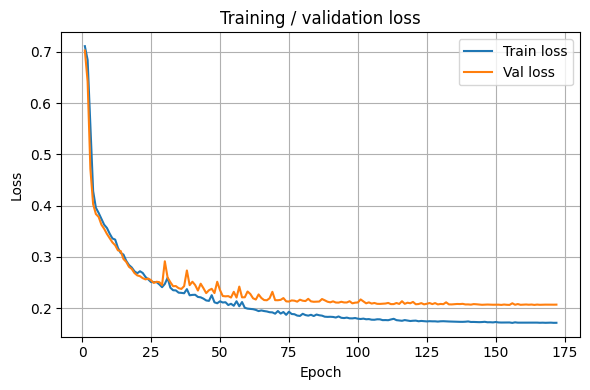

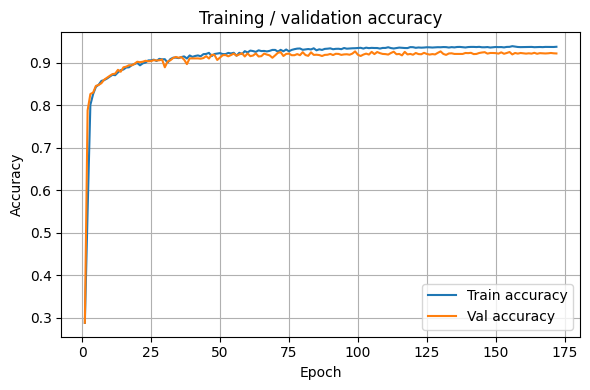

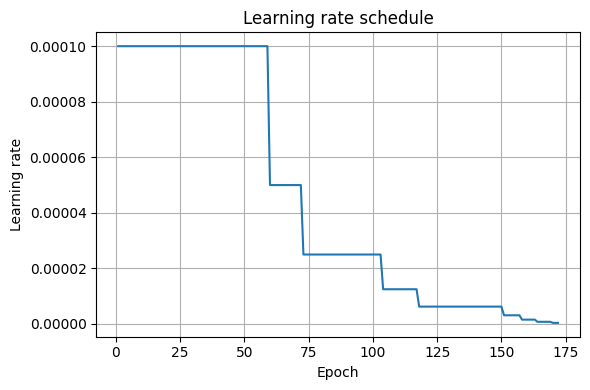

History saved to processed_chb_mit/seizure_cnn_history.pth
Model saved to processed_chb_mit/seizure_cnn_model.pth


In [ ]:
# 2. Train and evaluate model
model_path = os.path.join(PROCESSED_DIR, "seizure_cnn_model.pth")
history_path = os.path.join(PROCESSED_DIR, "seizure_cnn_history.pth")

if os.path.exists(model_path):
    print(f"Model exists loading from {model_path}")
    model = EEGCNN(in_channels=len(CHANNELS)).to(DEVICE)
    state = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    # Try to load saved training history if present
    history = None
    if os.path.exists(history_path):
        try:
            history = torch.load(history_path)
            print(f"Loaded training history from {history_path}")
        except Exception as e:
            logging.warning(f"Failed to load history from {history_path}: {e}")
            history = None
else:
    print("Training model from scratch...")
    model, history = train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test)

    # Save FP32 model weights
    torch.save(model.state_dict(), model_path)

    # Save training history (if available)
    try:
        if history is not None:
            torch.save(history, history_path)
            print(f"History saved to {history_path}")
    except Exception as e:
        logging.warning(f"Failed to save history to {history_path}: {e}")

    print(f"Model saved to {model_path}")

# Now you have:
# - model: loaded or newly trained (FP32)
# - history: training history dict (loaded if available or saved after training)

In [ ]:
# 3. Calculating FP32 model size, inference time, and performance
try:
    # ensure `model` is present
    model_fp32 = copy.deepcopy(model).cpu().eval()
except Exception:
    model_fp32 = None

print("\n------------------------------------------------------------------------------------------------------------------------")
print("BASELINE F32 EVALUATION\n")
print("Calculating FP32 model size, inference time, and performance...")
# --- Save FP32 state_dict & size ---
fp32_state_path = os.path.join(PROCESSED_DIR, "model_fp32_state.pth")
fp32_size = _save_state_dict_get_size_mb(model_fp32.state_dict(), fp32_state_path)

# --- Evaluate FP32 performance (AUC) ---
print("Evaluating Baseline FP32 model (CPU)...")
model_fp32.eval()
fp32_auc = evaluate_model_torch(model_fp32, X_test, y_test, device="cpu")

# --- Measure FP32 inference time ---
print("Running inference speed comparison (CPU)...")
fp32_time = measure_avg_inference_time(model_fp32, X_test, n_repeats=2)

# --- Print FP32 results ---
print(f"FP32 model size: {fp32_size:.2f} MB")
print(f"FP32 avg inference time: {fp32_time*1000:.2f} ms")
print(f"FP32 ROC AUC: {fp32_auc}")


------------------------------------------------------------------------------------------------------------------------
BASELINE F32 EVALUATION

Calculating FP32 model size, inference time, and performance...
Evaluating Baseline FP32 model (CPU)...
Running inference speed comparison (CPU)...
FP32 model size: 1.63 MB
FP32 avg inference time: 0.36 ms
FP32 ROC AUC: 0.9616804762998428


 # Stage 3 — SNN conversion & inference
 ---

In [ ]:
baseline = EEGCNN(in_channels=len(CHANNELS))
baseline.load_state_dict(torch.load(model_path, map_location=DEVICE))
baseline.to(DEVICE)
baseline.eval()

snn_model = copy.deepcopy(baseline)
snn_model.eval()

def max_activation(model, X_sample, DEVICE):
    act = {}
    def hook_output(name):
        def hook(model, input, output):
            output = output.detach().abs()
            val = torch.quantile(output.detach().abs(), 0.999).item()
            act[name] = max(1e-5,val)
        return hook

    hooks = []
    
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            hooks.append(m.register_forward_hook(hook_output(name)))
    try:
        X_tensor = torch.tensor(X_sample).float().to(DEVICE)
        input_max = torch.quantile(X_tensor.abs(), 0.999).item()
        with torch.no_grad():
            model(X_tensor)
    finally:
        for h in hooks: 
            h.remove()
    return act, input_max

max_activations, input_max = max_activation(baseline, X_test[:200], DEVICE)

layer_names = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6', 'fc1', 'fc2', 'fc3']
prev_max = input_max

with torch.no_grad():
    for name in layer_names:
        layer = dict(snn_model.named_modules())[name]
        curr_max = max_activations[name]

        layer.weight.data *= prev_max / curr_max
        if layer.bias is not None:
            layer.bias.data *= 1.0 / curr_max
        prev_max = curr_max

class IFNeuron(nn.Module):
    def __init__(self, th=1.0):
        super().__init__()
        self.th = th
    
    def forward(self, x, mem):
        mem += x
        spike = (mem >= self.th).float()
        mem = mem - spike * self.th # Soft reset
        return spike, mem

class SNN_Norm(nn.Module):
    def __init__(self, normalized_model):
        super().__init__()
        self.conv1 = normalized_model.conv1
        self.conv2 = normalized_model.conv2
        self.pool1 = normalized_model.pool1
        self.conv3 = normalized_model.conv3
        self.conv4 = normalized_model.conv4
        self.pool2 = normalized_model.pool2
        self.conv5 = normalized_model.conv5
        self.conv6 = normalized_model.conv6
        self.pool3 = normalized_model.pool3
        self.global_pool = normalized_model.global_pool
        self.fc1 = normalized_model.fc1
        self.fc2 = normalized_model.fc2
        self.fc3 = normalized_model.fc3

        self.neurons = nn.ModuleDict({name: IFNeuron(th=1.0) for name in ['conv1','conv2','conv3','conv4','conv5','conv6','fc1','fc2']})
        
    def forward(self, x_analog, time_steps):
        mem = {k: 0.0 for k in self.neurons.keys()}
        mem_out = 0.0
        outputs = []
        
        for t in range(time_steps):
            x = x_analog 
            x = self.conv1(x)
            x, mem['conv1'] = self.neurons['conv1'](x, mem['conv1'])
            x = self.conv2(x)
            x, mem['conv2'] = self.neurons['conv2'](x, mem['conv2'])
            x = self.pool1(x)
            
            x = self.conv3(x)
            x, mem['conv3'] = self.neurons['conv3'](x, mem['conv3'])
            x = self.conv4(x)
            x, mem['conv4'] = self.neurons['conv4'](x, mem['conv4'])
            x = self.pool2(x)
            
            x = self.conv5(x)
            x, mem['conv5'] = self.neurons['conv5'](x, mem['conv5'])
            x = self.conv6(x)
            x, mem['conv6'] = self.neurons['conv6'](x, mem['conv6'])
            x = self.pool3(x)
            
            x = self.global_pool(x).squeeze(-1)
            x = self.fc1(x)
            x, mem['fc1'] = self.neurons['fc1'](x, mem['fc1'])
            x = self.fc2(x)
            x, mem['fc2'] = self.neurons['fc2'](x, mem['fc2'])
                
            mem_out += self.fc3(x) 
            outputs.append(mem_out)
        return torch.stack(outputs)

snn = SNN_Norm(snn_model).to(DEVICE)

def inference(model, X_test, time_steps=50, batch_size=32):
    model.eval()
    logits = []
    
    X_scaled = X_test / input_max
    
    print(f"Inference: {len(X_test)} samples, {time_steps} steps")
    
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch = torch.tensor(X_scaled[i:i+batch_size]).float().to(DEVICE)
            voltage = model(batch, time_steps)
            
            # Recover logits
            final_logits = (voltage[-1].squeeze(-1) / time_steps) * max_activations['fc3']
            logits.extend(final_logits.cpu().numpy())
            
    logits_ = np.array(logits)
    probs = expit(logits_)
    return probs

probs = inference(snn, X_test, time_steps=50)

b_acc, b_th, thresholds = 0.0, 0.5, np.arange(0.1, 0.95, 0.05)

for th in thresholds:
    preds_adj = (probs > th).astype(int)
    acc = accuracy_score(y_test, preds_adj)
    
    if acc > b_acc:
        b_acc = acc
        b_th = th

print(f"\nBest Threshold: {b_th:.2f}")
print(f"Best Accuracy:  {b_acc:.4f}")

final_preds = (probs > b_th).astype(int)
print("\n=== SNN RESULTS ===")
print(classification_report(y_test, final_preds, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")

Inference: 2229 samples, 50 steps

Best Threshold: 0.15
Best Accuracy:  0.9228

=== SNN RESULTS ===
              precision    recall  f1-score   support

       False     0.9306    0.9635    0.9467      1587
        True     0.9010    0.8224    0.8599       642

    accuracy                         0.9228      2229
   macro avg     0.9158    0.8929    0.9033      2229
weighted avg     0.9221    0.9228    0.9217      2229

ROC AUC: 0.9555


 # STAGE 4- PRUNING
 ---
#### 4.1 CHANNEL PRUNING & 2:4 WEIGHT SPARSITY


--- Starting Channel Selection ---
Calculating Channel Sensitivity (Gradient Based)...

Top 8 Indices: [np.int64(0), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(15)]
New Channel List (8): ['FP1-F7', 'T7-P7', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F8', 'P8-O2']

--- Slicing Data to 8 Channels ---

--- Retraining Model on Reduced Input ---
New Input Shape: (6241, 8, 1024)
1/200 - 1s - 53ms/step - accuracy: 0.7119 - loss: 0.6703 - val_accuracy: 0.7148 - val_loss: 0.6618 - lr: 1.00e-04
2/200 - 1s - 52ms/step - accuracy: 0.7560 - loss: 0.6362 - val_accuracy: 0.7993 - val_loss: 0.5767 - lr: 1.00e-04
3/200 - 1s - 52ms/step - accuracy: 0.8199 - loss: 0.4798 - val_accuracy: 0.8280 - val_loss: 0.4197 - lr: 1.00e-04
4/200 - 1s - 53ms/step - accuracy: 0.8375 - loss: 0.4105 - val_accuracy: 0.8400 - val_loss: 0.3943 - lr: 1.00e-04
5/200 - 1s - 53ms/step - accuracy: 0.8486 - loss: 0.3932 - val_accuracy: 0.8456 - val_loss: 0.3867 - lr: 1.00e-04
6/200 - 1

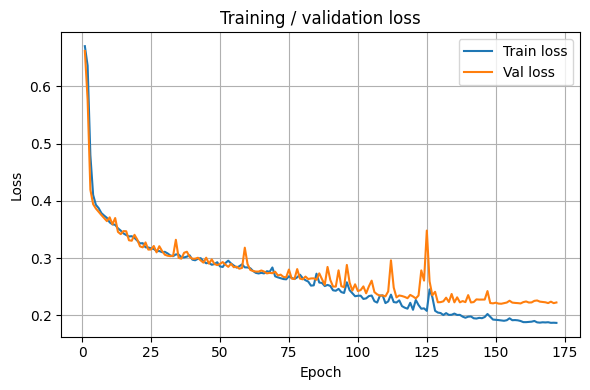

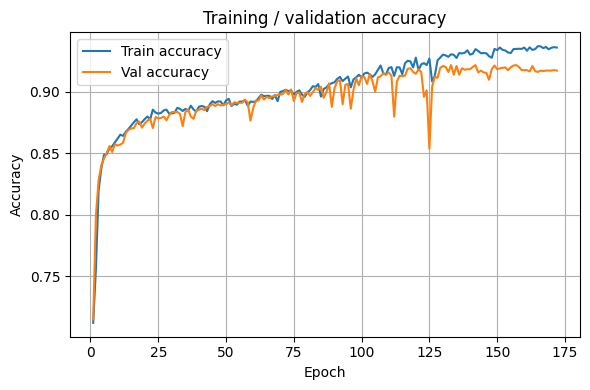

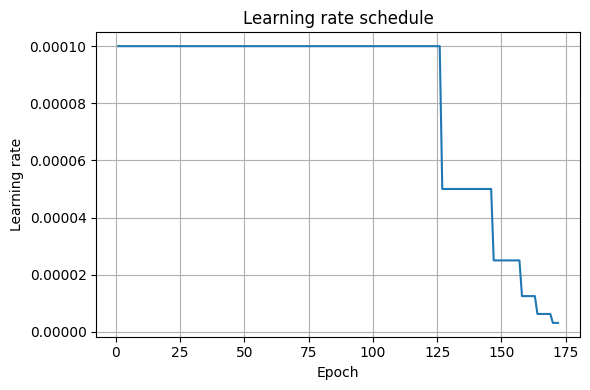

New Input Shape: (6241, 8, 1024)

--- Retraining Model on Reduced Input ---
1/200 - 1s - 53ms/step - accuracy: 0.7119 - loss: 0.6659 - val_accuracy: 0.7118 - val_loss: 0.6574 - lr: 1.00e-04
2/200 - 1s - 53ms/step - accuracy: 0.7388 - loss: 0.6346 - val_accuracy: 0.7921 - val_loss: 0.5847 - lr: 1.00e-04
3/200 - 1s - 53ms/step - accuracy: 0.8151 - loss: 0.4973 - val_accuracy: 0.8310 - val_loss: 0.4084 - lr: 1.00e-04
4/200 - 1s - 53ms/step - accuracy: 0.8411 - loss: 0.3979 - val_accuracy: 0.8445 - val_loss: 0.3853 - lr: 1.00e-04
5/200 - 1s - 53ms/step - accuracy: 0.8444 - loss: 0.3917 - val_accuracy: 0.8542 - val_loss: 0.3794 - lr: 1.00e-04
6/200 - 1s - 53ms/step - accuracy: 0.8535 - loss: 0.3812 - val_accuracy: 0.8475 - val_loss: 0.3862 - lr: 1.00e-04
7/200 - 1s - 53ms/step - accuracy: 0.8555 - loss: 0.3752 - val_accuracy: 0.8471 - val_loss: 0.3767 - lr: 1.00e-04
8/200 - 1s - 53ms/step - accuracy: 0.8547 - loss: 0.3696 - val_accuracy: 0.8594 - val_loss: 0.3648 - lr: 1.00e-04
9/200 - 1s -

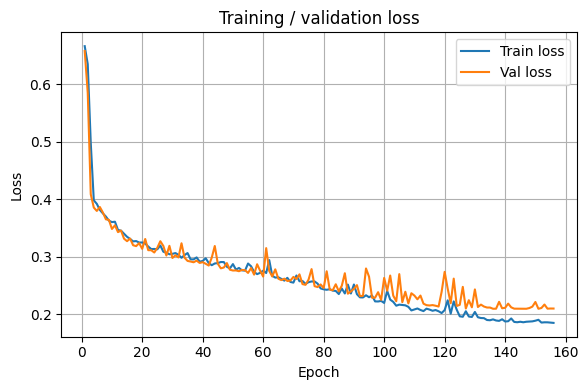

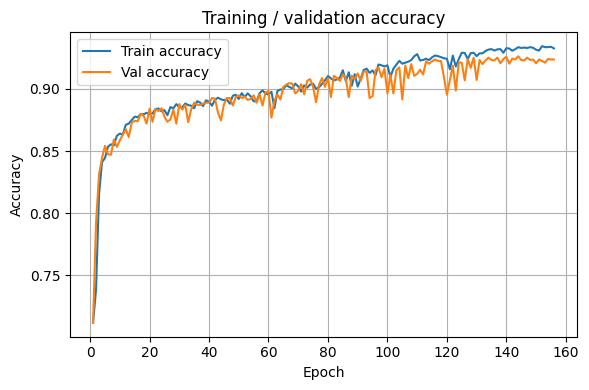

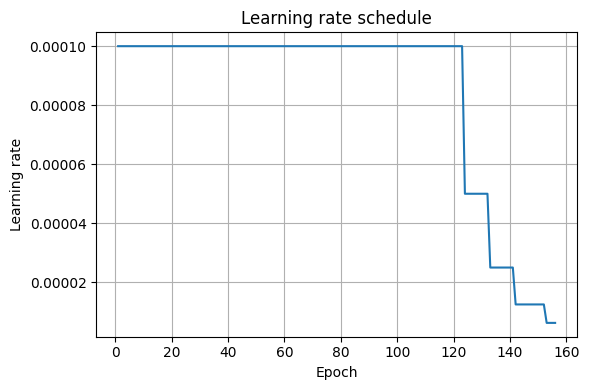


--- Applying 2:4 Weight Pruning ---
Applying 2:4 Weight Sparsity...
...Fine-tuning...
1/200 - 1s - 53ms/step - accuracy: 0.4309 - loss: 0.6954 - val_accuracy: 0.8093 - val_loss: 0.6845 - lr: 1.00e-04
2/200 - 1s - 53ms/step - accuracy: 0.8111 - loss: 0.6615 - val_accuracy: 0.8045 - val_loss: 0.6104 - lr: 1.00e-04
3/200 - 1s - 53ms/step - accuracy: 0.8114 - loss: 0.5188 - val_accuracy: 0.8303 - val_loss: 0.4217 - lr: 1.00e-04
4/200 - 1s - 53ms/step - accuracy: 0.8326 - loss: 0.4170 - val_accuracy: 0.8396 - val_loss: 0.3932 - lr: 1.00e-04
5/200 - 1s - 53ms/step - accuracy: 0.8423 - loss: 0.3966 - val_accuracy: 0.8449 - val_loss: 0.3870 - lr: 1.00e-04
6/200 - 1s - 53ms/step - accuracy: 0.8486 - loss: 0.3862 - val_accuracy: 0.8501 - val_loss: 0.3846 - lr: 1.00e-04
7/200 - 1s - 53ms/step - accuracy: 0.8540 - loss: 0.3784 - val_accuracy: 0.8538 - val_loss: 0.3675 - lr: 1.00e-04
8/200 - 1s - 53ms/step - accuracy: 0.8580 - loss: 0.3742 - val_accuracy: 0.8564 - val_loss: 0.3718 - lr: 1.00e-04
9

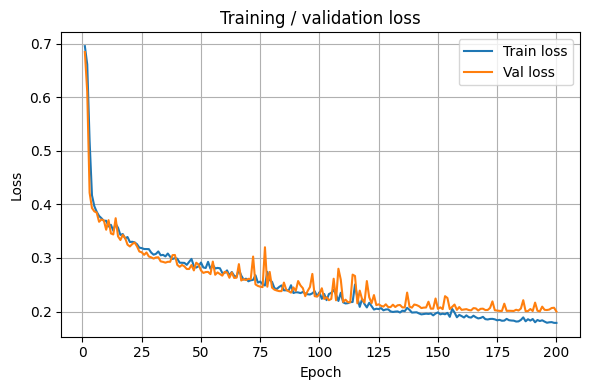

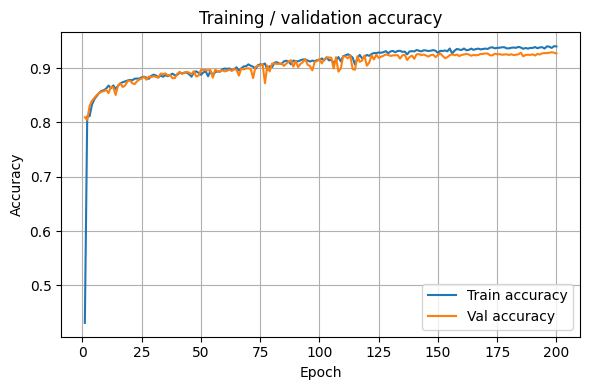

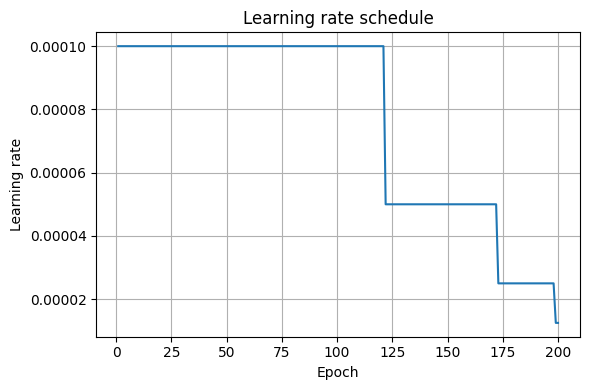


--- Visualizing Weight Sparsity (First Layer) ---


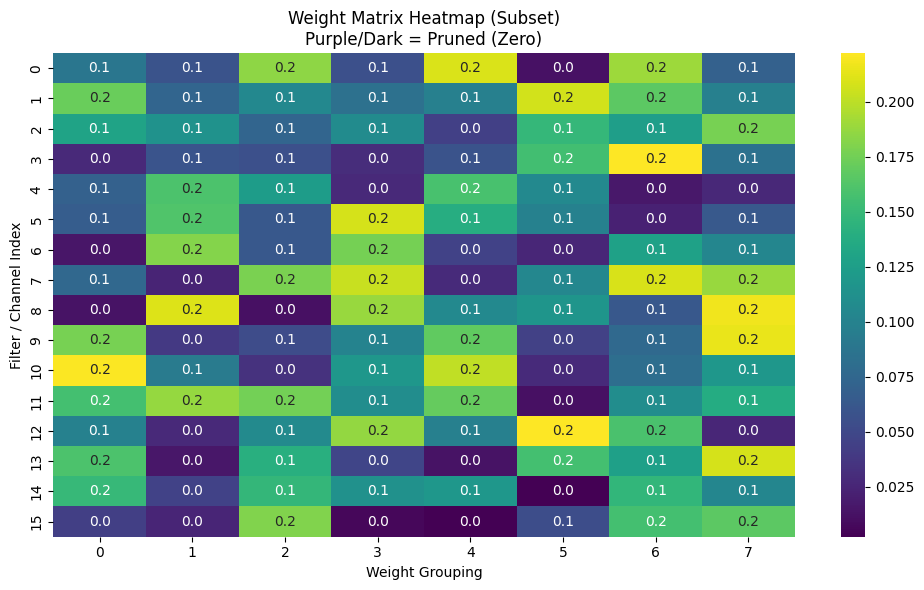


 Final pruned model saved to: processed_chb_mit/final_Q_SNN_Prune.pth


In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt
import os

class SeizurePruner:
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def rank_channels(self, data_loader, criterion):
        print("Calculating Channel Sensitivity (Gradient Based)...")
        self.model.eval()
        channel_scores = None
        limit_batches = 20 
        
        for i, (inputs, targets) in enumerate(data_loader):
            if i >= limit_batches: break
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            inputs.requires_grad_(True)
            
            self.model.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            grads = inputs.grad.abs()
            batch_scores = grads.sum(dim=(0, 2)).detach().cpu().numpy()
            
            if channel_scores is None:
                channel_scores = batch_scores
            else:
                channel_scores += batch_scores
                
        return channel_scores / np.max(channel_scores)

    def apply_weight_sparsity(self):
        print("Applying 2:4 Weight Sparsity...")
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)):
                w = module.weight.abs().clone()
                if w.numel() % 4 != 0: continue
                w_flat = w.view(-1, 4)
                thresholds, _ = torch.kthvalue(w_flat, k=2, dim=1, keepdim=True)
                mask = (w_flat > thresholds).float().view_as(module.weight)
                prune.custom_from_mask(module, name='weight', mask=mask)

    def make_permanent(self):
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)) and prune.is_pruned(module):
                prune.remove(module, 'weight')
def fine_tune_sparse_model(model, train_loader, val_loader, epochs=10):
    """
    Trains the EXISTING model. Does not reset weights.
    This allows the model to 'heal' after pruning.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Low learning rate
    criterion = nn.BCEWithLogitsLoss()
    model.train()
    
    print(f"Fine-tuning sparse model for {epochs} epochs...")
    
    for epoch in range(epochs):
        # Train
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
        # Quick Validation log
        print(f"Epoch {epoch+1}/{epochs} finished healing.")
        
    return model
#Execution

print("\n--- Starting Channel Selection ---")
X_val_t = torch.from_numpy(X_val).float()
y_val_t = torch.from_numpy(y_val.astype(np.float32))
val_loader_prune = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

# Rank Channels
pruner = SeizurePruner(model, DEVICE)
scores = pruner.rank_channels(val_loader_prune, nn.BCEWithLogitsLoss())

#Select Top 8 Channels
top_k_indices = np.argsort(scores)[::-1][:8]
top_k_indices = sorted(top_k_indices)

# We must update this list so 'train_and_evaluate' builds the correct model size (8 instead of 18).
#Backup original list
ORIGINAL_CHANNELS = list(CHANNELS)
CHANNELS = [ORIGINAL_CHANNELS[i] for i in top_k_indices] 

print(f"\nTop 8 Indices: {top_k_indices}")
print(f"New Channel List ({len(CHANNELS)}): {CHANNELS}")

#Prune Dataset
print("\n--- Slicing Data to 8 Channels ---")
X_train_pruned = X_train[:, top_k_indices, :]
X_val_pruned   = X_val[:, top_k_indices, :]
X_test_pruned  = X_test[:, top_k_indices, :]

print(f"New Input Shape: {X_train_pruned.shape}")

#Retrain Model
print("\n--- Retraining Model on Reduced Input ---")
pruned_model, history_pruned = train_and_evaluate(
    X_train_pruned, y_train,
    X_val_pruned, y_val,
    X_test_pruned, y_test
)

# Weight Pruning
print("\n--- Applying 2:4 Weight Pruning ---")
final_pruner = SeizurePruner(pruned_model, DEVICE)
final_pruner.apply_weight_sparsity()

# Fine-Tune 
X_tr_t = torch.from_numpy(X_train_pruned).float()
y_tr_t = torch.from_numpy(y_train.astype(np.float32))
train_loader_pruned = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

# Re-use validation loader
X_val_t = torch.from_numpy(X_val_pruned).float()
y_val_t = torch.from_numpy(y_val.astype(np.float32))
val_loader_pruned = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

# Run the fine-tune process
pruned_model = fine_tune_sparse_model(pruned_model, train_loader_pruned, val_loader_pruned, epochs=15)

final_pruner.make_permanent()

save_path = os.path.join(PROCESSED_DIR, "final_Q_SNN_Prune.pth")
torch.save(pruned_model.state_dict(), save_path)
print(f"\n Final pruned model saved to: {save_path}")
import seaborn as sns

def plot_weight_sparsity(model):
    print("\n--- Visualizing Weight Sparsity (First Layer) ---")
        
    layer = model.conv1 
    weights = layer.weight.data.cpu().numpy()
    
    
    w_flat = weights.flatten()
    
    subset_size = 128 
    if w_flat.size >= subset_size:
        w_subset = w_flat[:subset_size].reshape(16, 8)
        
        plt.figure(figsize=(10, 6))
        sns.heatmap(np.abs(w_subset), annot=True, fmt=".1f", cmap="viridis", cbar=True)
        
        plt.title("Weight Matrix Heatmap (Subset)\nPurple/Dark = Pruned (Zero)")
        plt.xlabel("Weight Grouping")
        plt.ylabel("Filter / Channel Index")
        plt.tight_layout()
        plt.show()
    else:
        print("Layer too small for this specific visualization.")

plot_weight_sparsity(pruned_model)

In [ ]:

# FINAL EVALUATION: PRUNED CNN 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

print("\n--- Evaluating Pruned Model (CNN) ---")

X_test_pruned = X_test[:, top_k_indices, :]
y_test_numpy = y_test.astype(np.float32)

def inference_cnn(model, X_data, batch_size=256):
    model.eval()
    
    dataset = TensorDataset(torch.from_numpy(X_data).float(), torch.zeros(len(X_data)))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    all_probs = []
    
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(DEVICE)
            logits = model(inputs)
            probs = torch.sigmoid(logits) # Sigmoid for CNN probabilities
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_probs)

probs = inference_cnn(pruned_model, X_test_pruned)

b_acc, b_th = 0.0, 0.5
thresholds = np.arange(0.1, 0.95, 0.05)

for th in thresholds:
    preds_adj = (probs > th).astype(int)
    acc = accuracy_score(y_test_numpy, preds_adj)
    
    if acc > b_acc:
        b_acc = acc
        b_th = th

print(f"\nBest Threshold: {b_th:.2f}")
print(f"Best Accuracy:  {b_acc:.4f}")

final_preds = (probs > b_th).astype(int)
print("\n=== PRUNED MODEL RESULTS ===")
print(classification_report(y_test_numpy, final_preds, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test_numpy, probs):.4f}")

--- Running Final Evaluation ---

=== FINAL RESULTS TABLE ===
| Metric         | Baseline     | Pruned       | Change   |
|:---------------|:-------------|:-------------|:---------|
| Accuracy       | 93.00%       | 93.09%       | 0.09%    |
| F1-Score       | 87.56%       | 87.44%       | -0.12%   |
| Input Channels | 18           | 8            | -55%     |
| Model Weights  | 100% (Dense) | 50% (Sparse) | -50%     |


In [ ]:
model_pruned = pruned_model
pruned_size = _save_state_dict_get_size_mb(model_pruned.state_dict(), channel_sparse_path)

# --- Evaluate FP32 performance (AUC) ---
print("Evaluating Pruned model (CPU)...")
model_pruned.eval()
pruned_auc = evaluate_model_torch(model_pruned, X_test_pruned, y_test, device="cpu")

# --- Measure Pruned time ---
print("Running inference speed comparison (CPU)...")
pruned_time = measure_avg_inference_time(model_pruned, X_test_pruned, n_repeats=2)

# --- Print Pruned results ---
print(f"PRUNED model size: {pruned_size:.2f} MB")
print(f"PRUNED avg inference time: {pruned_time*1000:.2f} ms")
print(f"PRUNED ROC AUC: {pruned_auc}")

Evaluating Pruned model (CPU)...
Running inference speed comparison (CPU)...
PRUNED model size: 1.63 MB
PRUNED avg inference time: 0.35 ms
PRUNED ROC AUC: 0.9609345401794566


In [ ]:
# Results logging and reporting
RESULT_COLUMNS = [
    "Model",
    "Size (MB)",
    "Compression (x)",
    "Compression (%)",
    "Inference time (ms)",
    "Speedup Δ%",
    "AUC",
    "AUC drop",
    "AUC Δ%"
] + CLASS_COLUMNS

results_df = pd.DataFrame(columns=RESULT_COLUMNS)

def pct(delta):
    if delta is None:
        return ""
    return f"{delta:+.2f}%"

def safe_pct(num, denom):
    try:
        return 100 * (num - denom) / denom
    except:
        return None

def add(name, model=None, size=None, inference_time=None, metrics=None, eval_device="cpu"):
    global results_df

    if metrics is None:
        if model is not None:
            metrics = collect_all_metrics_torch(model, device=eval_device)
        else:
            metrics = {}
            for col in BASE_CLASS_COLUMNS:
                metrics[col] = 0 if "Support" in col else np.nan

    test_auc = metrics.get("Test ROC AUC")
    # val metrics included within `metrics`
    size_mb = round(size, 4) if size is not None else None
    inference_ms = round(inference_time * 1000, 4) if inference_time is not None else None

    is_baseline = len(results_df) == 0
    base = results_df.iloc[0] if not is_baseline else None

    # Absolute values
    if is_baseline:
        compression_x = 1.0
        compression_pct = 0.0
        auc_drop = 0.0 if test_auc is not None else None
        acc_pct = 0.0 if test_auc is not None else None
        speed_pct = 0.0
    else:
        base_size = base["Size (MB)"]
        base_time = base["Inference time (ms)"]
        base_auc = base.get("Test ROC AUC")

        compression_x = None
        compression_pct = None
        if base_size not in (None, 0) and size_mb not in (None, 0):
            compression_x = base_size / size_mb
            compression_pct = (1 - size_mb / base_size) * 100

        auc_drop = None
        acc_pct = None
        if base_auc is not None and test_auc is not None:
            auc_drop = base_auc - test_auc
            acc_pct = safe_pct(test_auc, base_auc)

        speed_pct = None
        if base_time not in (None, 0) and inference_ms not in (None, 0):
            speed_pct = safe_pct(base_time, inference_ms)

    row = {
        "Model": name,
        "Size (MB)": size_mb,
        "Compression (x)": round(compression_x, 4) if compression_x is not None else None,
        "Compression (%)": round(compression_pct, 2) if compression_pct is not None else None,
        "Inference time (ms)": inference_ms,
        "Speedup Δ%": pct(speed_pct),
        "AUC": round(test_auc, 6) if test_auc is not None else None,
        "AUC drop": round(auc_drop, 6) if auc_drop is not None else None,
        "AUC Δ%": pct(acc_pct)
    }

    for col in BASE_CLASS_COLUMNS:
        value = metrics.get(col)
        row[col] = value
        delta_col = f"{col} Δ"
        delta_pct_col = f"{col} Δ%"
        if is_baseline:
            if _is_valid_number(value):
                row[delta_col] = 0 if isinstance(value, (int, np.integer)) else 0.0
                row[delta_pct_col] = "+0.00%"
            else:
                row[delta_col] = None
                row[delta_pct_col] = ""
        else:
            base_value = base.get(col)
            row[delta_col] = _delta_value(value, base_value)
            row[delta_pct_col] = _delta_pct(value, base_value)

    if is_baseline:
        results_df.loc[0] = row
    else:
        results_df.loc[len(results_df)] = row

 # STAGE 5 - QUANTIZATION
 ---
#### 5.1. DYNAMIC POST-TRAINING QUANTIZATION

In [ ]:
# 5.1. DYNAMIC POST-TRAINING QUANTIZATION
print("\n------------------------------------------------------------------------------------------------------------------------")
print("DYNAMIC POST-TRAINING QUANTIZATION\n")
int8_dyn_state_path = os.path.join(PROCESSED_DIR, "model_int8_dynamic_state.pth")
int8_dyn_state_path_pruned = os.path.join(PROCESSED_DIR, "model_int8_dynamic_state_pruned.pth")
CHANNELS = ORIGINAL_CHANNELS  # Reset CHANNELS to original for quantization eval
# File doesn't exist: quantize and save
model_int8_dynamic = torch.quantization.quantize_dynamic(
    copy.deepcopy(model_fp32),
    {nn.Linear},
    dtype=torch.qint8
)

int8_dyn_size = _save_state_dict_get_size_mb(model_int8_dynamic.state_dict(), int8_dyn_state_path)

# --- Measure INT8 inference time (quantized models run on CPU) ---
print("Evaluating Dynamic INT8 model (CPU)...")
int8_dyn_time = measure_avg_inference_time(model_int8_dynamic, X_test, n_repeats=2, device='cpu')

# --- Evaluate INT8 dynamic performance (AUC) ---
print("Running inference speed comparison (CPU)...")
int8_dyn_auc = evaluate_model_torch(model_int8_dynamic, X_test, y_test, device='cpu')

# --- Record results ---
add("FP32", model=model_fp32, size=fp32_size, inference_time=fp32_time)
add("Dynamic INT8", model=model_int8_dynamic, size=int8_dyn_size, inference_time=int8_dyn_time)
print("Dynamic Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
DYNAMIC POST-TRAINING QUANTIZATION

Evaluating Dynamic INT8 model (CPU)...
Running inference speed comparison (CPU)...
Dynamic Quantization Comparison Finished!
       Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.00000,+0.00%,0.9389,0.0,+0.00%,0.9517,0.0,+0.00%,0.9452,0.0,+0.00%,1904,0.0,+0.00%,0.8765,0.0,+0.00%,0.847,0.0,+0.00%,0.8615,0.0,+0.00%,771,0.0,+0.00%,0.9215,0.0,+0.00%,0.9077,0.0,+0.00%,0.8993,0.0,+0.00%,0.9034,0.0,+0.00%,0.9209,0.0,+0.00%,0.9215,0.0,+0.00%,0.9211,0.0,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.00027,-0.03%,0.9389,0.0,+0.00%,0.9517,0.0,+0.00%,0.9452,0.0,+0.00%,1904,0.0,+0.00%,0.8765,0.0,+0.00%,0.847,0.0,+0.00%,0.8615,0.0,+0.00%,771,0.0,+0.00%,0.9215,0.0,+0.00%,0.9077,0.0,+0.00%,0.8993,0.0,+0.00%,0.9034,0.0,+0.00%,0.9209,0.0,+0.00%,0.9215,0.0,+0.00%,0.9211,0.0,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%


 ---
#### 5.2. STATIC (EAGER) POST-TRAINING QUANTIZATION

In [ ]:
# 5.2. STATIC (EAGER) POST-TRAINING QUANTIZATION
print("\n------------------------------------------------------------------------------------------------------------------------")
print("STATIC (EAGER) POST-TRAINING QUANTIZATION\n")

torch.backends.quantized.engine = "fbgemm"

# ----------------------------- # 1. Calibration DataLoader # ----------------------------- 
def get_calibration_loader_eager(X, batch_size=32, n_samples=512): 
    """Small subset of training data for calibration.""" 
    idx = np.random.choice(len(X), size=min(n_samples, len(X)), replace=False) 
    X_cal = torch.from_numpy(X[idx]).float() 
    dummy_y = torch.zeros(len(X_cal)) # labels not needed 
    ds = TensorDataset(X_cal, dummy_y) 
    return DataLoader(ds, batch_size=batch_size, shuffle=False) 

calib_loader_eager = get_calibration_loader_eager(X_train) 

# ----------------------------- 
# 2. Wrapper with QuantStub / DeQuantStub 
# ----------------------------- 
class QuantWrapper(nn.Module): 
    """ Wraps an existing float model with QuantStub and DeQuantStub so we can use eager static quantization without touching EEGCNN. """ 
    def __init__(self, float_model: nn.Module): 
        super().__init__() 
        self.quant = tq.QuantStub() 
        self.model = float_model 
        self.dequant = tq.DeQuantStub() 
    
    def forward(self, x): 
        x = self.quant(x) 
        x = self.model(x) 
        x = self.dequant(x)
        return x


# ============================================================
# HELPER: Build, calibrate, convert, save, evaluate
# ============================================================
def run_static_eager_quantization(
    float_model,
    X_train_data,
    X_test_data,
    y_test_data,
    name_suffix
):
    """
    Performs:
    - Wrap model in QuantStub/DeQuantStub
    - prepare()
    - calibration
    - convert()
    - save .pth
    - evaluate/duration
    - returns metrics + updates results_df via add()
    """

    print(f"\n===== Static Eager Quantization: {name_suffix} =====")

    # Calibration loader (subset of training data)
    calib_loader = get_calibration_loader_eager(X_train_data)

    # Wrap in Q/DQ stubs
    float_cp = copy.deepcopy(float_model).cpu().eval()
    eager_model = QuantWrapper(float_cp).cpu().eval()

    # QConfig
    eager_model.qconfig = tq.get_default_qconfig("fbgemm")

    # Prepare
    print("Preparing model...")
    tq.prepare(eager_model, inplace=True)

    # Calibration
    print("Calibrating model...")
    with torch.no_grad():
        for xb, _ in calib_loader:
            xb = _format_tensor_for_model(xb, eager_model).to("cpu")
            _ = eager_model(xb)

    # Convert
    print("Converting to INT8...")
    model_int8 = tq.convert(eager_model, inplace=False).eval()

    # Save
    out_path = os.path.join(PROCESSED_DIR, f"model_int8_static_eager_{name_suffix}.pth")
    int8_size = _save_state_dict_get_size_mb(model_int8.state_dict(), out_path)

    # Evaluate INT8
    print("Evaluating INT8 model (CPU)...")
    auc = evaluate_model_torch(model_int8, X_test_data, y_test_data, device="cpu")

    print("Benchmarking inference time (CPU)...")
    speed = measure_avg_inference_time(model_int8, X_test_data, n_repeats=2)

    # Add to big result table
    add(f"Static Eager INT8 ({name_suffix})", model=model_int8, size=int8_size, inference_time=speed)

    print(f"✔ Done Static Eager ({name_suffix}) — AUC={auc:.4f}, size={int8_size:.2f} MB, time={speed*1000:.2f} ms")
    return model_int8, auc, int8_size, speed



# ============================================================
# RUN STATIC EAGER FOR FP32 MODEL
# ============================================================
print("\n### Running Static Eager — Baseline FP32")
model_int8_static_fp32, auc_fp32, size_fp32, time_fp32 = run_static_eager_quantization(
    float_model=model_fp32,
    X_train_data=X_train,
    X_test_data=X_test,
    y_test_data=y_test,
    name_suffix="fp32"
)


print("\nStatic Eager PTQ for BOTH FP32 completed!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
STATIC (EAGER) POST-TRAINING QUANTIZATION


### Running Static Eager — Baseline FP32

===== Static Eager Quantization: fp32 =====
Preparing model...
Calibrating model...
Converting to INT8...
Evaluating INT8 model (CPU)...
Benchmarking inference time (CPU)...
✔ Done Static Eager (fp32) — AUC=0.9605, size=0.44 MB, time=0.33 ms

Static Eager PTQ for BOTH FP32 completed!
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  V

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.00000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.000,+0.00%,0.9209,0.000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.00027,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.000,+0.00%,0.9209,0.000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.00042,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.005,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.001,-0.11%,0.9199,-0.001,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%


 ---
#### 5.3. STATIC QUANTIZATION (FX GRAPH MODE)

In [ ]:
# 5.3. STATIC QUANTIZATION (FX GRAPH MODE)
print("\n------------------------------------------------------------------------------------------------------------------------")
print("STATIC FX QUANTIZATION\n")
print("Starting Static FX Quantization Comparison...")

# -----------------------------
# 1. Build Calibration Dataloader
# -----------------------------
def get_calibration_loader(X, batch_size=32, n_samples=512):
    idx = np.random.choice(len(X), size=min(n_samples, len(X)), replace=False)
    X_cal = torch.from_numpy(X[idx]).float()
    dummy_y = torch.zeros(len(X_cal))
    ds = TensorDataset(X_cal, dummy_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

calibration_loader = get_calibration_loader(X_train)

model_static = copy.deepcopy(model_fp32).cpu().eval()

qconfig = get_default_qconfig_mapping("fbgemm")   # CPU int8 quantization backend

example_input = _example_input_for_model(model_static, X_train.shape[1], X_train.shape[2])
prepared_model = prepare_fx(model_static, qconfig, example_inputs=example_input)

print("Running calibration over sample training data...")
with torch.no_grad():
    for xb, _ in calibration_loader:
        xb = _format_tensor_for_model(xb, prepared_model)
        prepared_model(xb)

model_int8_static = convert_fx(prepared_model)
print("Static FX quantization completed")

int8_static_path = os.path.join(PROCESSED_DIR, "model_int8_static_state.pth")
int8_static_size = _save_state_dict_get_size_mb(model_int8_static.state_dict(), int8_static_path)

print("Evaluating Static INT8 model...")
static_auc = evaluate_model_torch(model_int8_static, X_test, y_test, device="cpu")

print("Running inference speed comparison (CPU)...")
static_time = measure_avg_inference_time(model_int8_static, X_test, n_repeats=2, device="cpu")

add("Static FX INT8", model=model_int8_static, size=int8_static_size, inference_time=static_time)
print("Static FX Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
STATIC FX QUANTIZATION

Starting Static FX Quantization Comparison...
Running calibration over sample training data...
Static FX quantization completed
Evaluating Static INT8 model...
Running inference speed comparison (CPU)...
Static FX Quantization Comparison Finished!
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
#### 5.4. QUANTIZATION-AWARE TRAINING (QAT) WITH FX

In [ ]:
# 5.4. QUANTIZATION-AWARE TRAINING (QAT) WITH FX
print("\n------------------------------------------------------------------------------------------------------------------------")
print("QUANTIZATION-AWARE TRAINING (QAT)\n")

int8_qat_path = os.path.join(PROCESSED_DIR, "model_int8_qat_fx_state.pth")
model_int8_qat = None
int8_qat_size = None

if model_fp32 is None:
    logging.warning("Skipping QAT: baseline FP32 model not available.")
else:
    # Use same engine as other quantization
    torch.backends.quantized.engine = "fbgemm"

    # -----------------------------
    # 1. Build train dataloader for QAT
    # -----------------------------
    def get_qat_train_loader(X, y, batch_size=128):
        X_t = torch.from_numpy(X).float()
        y_t = torch.from_numpy(y.astype(np.float32))
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=batch_size, shuffle=True)

    qat_train_loader = get_qat_train_loader(X_train, y_train, batch_size=min(128, BATCH_SIZE))

    # We can also use a small val loader if you want to monitor val loss (optional)
    qat_val_loader = get_qat_train_loader(X_val, y_val, batch_size=min(256, BATCH_SIZE))

    # -----------------------------
    # 2. Prepare model for QAT (FX)
    # -----------------------------
    print("Preparing baseline model for QAT (FX)...")

    # Start from baseline FP32 model
    model_fp32_for_qat = copy.deepcopy(model_fp32).cpu().eval()

    # Create QAT qconfig mapping
    try:
        qat_qconfig_mapping = get_default_qat_qconfig_mapping("fbgemm")
    except TypeError:
        # Older API fallback (unlikely, but just in case)
        qat_qconfig_mapping = {"": get_default_qat_qconfig("fbgemm")}

    example_input = _example_input_for_model(model_fp32_for_qat, X_train.shape[1], X_train.shape[2])

    # Prepare QAT graph
    model_qat_prepared = prepare_qat_fx(
        model_fp32_for_qat,
        qat_qconfig_mapping,
        example_inputs=example_input
    )

    if os.path.exists(int8_qat_path):
        print(f"Loading saved QAT INT8 model from {int8_qat_path}")
        model_qat_prepared = model_qat_prepared.eval()
        model_int8_qat = convert_fx(model_qat_prepared)
        state = torch.load(int8_qat_path, map_location="cpu")
        model_int8_qat.load_state_dict(state)
        int8_qat_size = os.path.getsize(int8_qat_path) / (1024.0 * 1024.0)
        print("Loaded QAT INT8 weights  skipping retraining.")
    else:
        print("QAT model prepared (fake quant + observers inserted).")

        # -----------------------------
        # 3. Train the QAT model (a few epochs)
        # -----------------------------
        QAT_EPOCHS = 20  # you can increase to ~1020 if you want better tuning

        model_qat = model_qat_prepared.train()
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model_qat.parameters(), lr=LEARNING_RATE)

        device_qat = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Training QAT model on: {device_qat}")
        model_qat.to(device_qat)

        for epoch in range(1, QAT_EPOCHS + 1):
            model_qat.train()
            running_loss = 0.0
            total = 0

            for xb, yb in qat_train_loader:
                xb = _format_tensor_for_model(xb, model_qat).to(device_qat)
                yb = yb.to(device_qat)

                optimizer.zero_grad()
                logits = model_qat(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * xb.size(0)
                total += yb.numel()

            train_loss = running_loss / total

            # Optional: simple val loss monitor
            model_qat.eval()
            val_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for xb, yb in qat_val_loader:
                    xb = _format_tensor_for_model(xb, model_qat).to(device_qat)
                    yb = yb.to(device_qat)
                    logits = model_qat(xb)
                    loss = criterion(logits, yb)
                    val_loss += loss.item() * xb.size(0)
                    val_total += yb.numel()
            val_loss /= max(1, val_total)

            print(f"Epoch {epoch}/{QAT_EPOCHS} - QAT train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

        print("QAT training finished.")

        # -----------------------------
        # 4. Convert QAT model to INT8 (FX)
        # -----------------------------
        print("Converting QAT model to static INT8 (FX)...")
        model_qat_cpu = model_qat.to("cpu").eval()
        model_int8_qat = convert_fx(model_qat_cpu)
        print("QAT  INT8 model conversion done.")

        # -----------------------------
        # 5. Save QAT INT8 model & measure size
        # -----------------------------
        int8_qat_size = _save_state_dict_get_size_mb(model_int8_qat.state_dict(), int8_qat_path)

if model_int8_qat is None:
    print("QAT INT8 model unavailable skipping evaluation/comparison.")
    qat_auc = None
    qat_time = None
else:
    # -----------------------------
    # 6. Evaluate AUC on test set
    # -----------------------------
    print("QAT FX quantization completed")

    # Save & measure size
    qat_int8_path = os.path.join(PROCESSED_DIR, "model_int8_qat_state.pth")
    qat_int8_size = _save_state_dict_get_size_mb(model_int8_qat.state_dict(), qat_int8_path)

    print("Evaluating QAT FX INT8 model...")
    qat_auc = evaluate_model_torch(model_int8_qat, X_test, y_test, device="cpu")

    print("Running inference speed comparison (CPU)...")
    qat_time = measure_avg_inference_time(model_int8_qat, X_test, n_repeats=2, device="cpu")

    # Add to results table
    add("QAT FX INT8", model=model_int8_qat, size=qat_int8_size, inference_time=qat_time)

    # Show updated results DataFrame
    print("QAT FX Quantization Comparison Finished!")

print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
QUANTIZATION-AWARE TRAINING (QAT)

Preparing baseline model for QAT (FX)...
QAT model prepared (fake quant + observers inserted).
Training QAT model on: cuda
Epoch 1/20 - QAT train_loss: 0.1951 - val_loss: 0.2114
Epoch 2/20 - QAT train_loss: 0.1845 - val_loss: 0.2157
Epoch 3/20 - QAT train_loss: 0.1868 - val_loss: 0.2079
Epoch 4/20 - QAT train_loss: 0.1803 - val_loss: 0.2034
Epoch 5/20 - QAT train_loss: 0.1857 - val_loss: 0.2038
Epoch 6/20 - QAT train_loss: 0.1809 - val_loss: 0.2009
Epoch 7/20 - QAT train_loss: 0.1755 - val_loss: 0.2015
Epoch 8/20 - QAT train_loss: 0.1795 - val_loss: 0.2171
Epoch 9/20 - QAT train_loss: 0.1772 - val_loss: 0.2117
Epoch 10/20 - QAT train_loss: 0.1739 - val_loss: 0.2011
Epoch 11/20 - QAT train_loss: 0.1701 - val_loss: 0.2143
Epoch 12/20 - QAT train_loss: 0.1694 - val_loss: 0.2591
Epoch 13/20 - QAT train_loss: 0.1766 - val_loss: 0.2414
E

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
#### 5.5. ONNX EXPORT + INT8 QUANTIZATION

In [ ]:
# 5.5. ONNX EXPORT + INT8 QUANTIZATION
import onnx
import onnxruntime as ort
import onnxruntime.quantization.quant_utils as qutils
from onnxruntime.quantization import (
    quantize_dynamic, quantize_static, QuantType, CalibrationDataReader
)
from onnx import TensorProto

print("\n------------------------------------------------------------------------------------------------------------------------")
print("ONNX EXPORT + INT8 QUANTIZATION\n")

# ============================================================
# 0. PATCH  Disable ONNX shape inference everywhere
# ============================================================

def _skip_shape_inference(model_path: str):
    # ORT will call this instead of running inference
    return onnx.load(model_path)

qutils.load_model_with_shape_infer = _skip_shape_inference

# ============================================================
# 1. EXPORT FP32 MODEL TO ONNX (cache-aware)
# ============================================================

onnx_fp32_path = os.path.join(PROCESSED_DIR, "seizure_cnn_fp32.onnx")
onnx_int8_dynamic_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_dynamic.onnx")
onnx_int8_static_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_static.onnx")

fp32_onnx_available = os.path.exists(onnx_fp32_path)
onnx_input_rank = None
if fp32_onnx_available:
    try:
        onnx_input_rank = len(onnx.load(onnx_fp32_path).graph.input[0].type.tensor_type.shape.dim)
    except Exception:
        onnx_input_rank = None

if not fp32_onnx_available:
    if model_fp32 is None:
        logging.warning("Skipping ONNX export: FP32 model not available and no cached ONNX file found.")
    else:
        dummy = _example_input_for_model(model_fp32, X_train.shape[1], X_train.shape[2]).cpu()
        print("Exporting FP32 model to ONNX (opset 18)")
        torch.onnx.export(
            model_fp32.cpu(),
            dummy,
            onnx_fp32_path,
            export_params=True,
            opset_version=18,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
        )
        fp32_onnx_available = True
        try:
            onnx_input_rank = len(onnx.load(onnx_fp32_path).graph.input[0].type.tensor_type.shape.dim)
        except Exception:
            onnx_input_rank = None
        print("Saved ONNX:", onnx_fp32_path)
else:
    print(f"Found cached FP32 ONNX model at {onnx_fp32_path}")

# ============================================================
# 2. BASELINE ONNX FP32 INFERENCE
# ============================================================

def onnx_predict(sess, X, batch=32):
    input_meta = sess.get_inputs()[0]
    input_rank = len(input_meta.shape)
    name = input_meta.name
    outs = []
    for i in range(0, len(X), batch):
        xb = X[i:i+batch].astype(np.float32)
        if input_rank == 4:
            xb = xb[:, None, :, :]
        logits = sess.run(None, {name: xb})[0]
        logits = np.clip(logits, -30, 30)
        outs.append(1 / (1 + np.exp(-logits)))
    return np.concatenate(outs).ravel()

def eval_onnx(path):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    probs = onnx_predict(sess, X_test)
    auc = roc_auc_score(y_test, probs)
    return auc, probs

def collect_all_metrics_onnx(model_path: str, batch: int = 32):
    if not os.path.exists(model_path):
        return None
    try:
        sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    except Exception as e:
        logging.warning(f"collect_all_metrics_onnx: failed to load {model_path}: {e}")
        return None

    metrics = {}
    val_probs = onnx_predict(sess, X_val, batch=batch)
    metrics.update(_metrics_from_probs(y_val, val_probs, "Val"))

    test_probs = onnx_predict(sess, X_test, batch=batch)
    metrics.update(_metrics_from_probs(y_test, test_probs, "Test"))
    return metrics

fp32_onnx_auc = None
if fp32_onnx_available:
    print("Evaluating FP32 ONNX baseline")
    fp32_onnx_auc, _ = eval_onnx(onnx_fp32_path)
    print("FP32 ONNX AUC:", fp32_onnx_auc)
else:
    logging.warning("FP32 ONNX model unavailable  skipping baseline ONNX evaluation.")

# ============================================================
# 3. DYNAMIC INT8 QUANTIZATION (cache-aware)
# ============================================================

dyn_onnx_available = os.path.exists(onnx_int8_dynamic_path)

if dyn_onnx_available:
    print(f"Using cached Dynamic INT8 ONNX model at {onnx_int8_dynamic_path}")
elif fp32_onnx_available:
    print("ONNX Dynamic INT8 quantization")
    quantize_dynamic(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_dynamic_path,
        weight_type=QuantType.QInt8,
        op_types_to_quantize=["MatMul", "Gemm"],
        use_external_data_format=False,
        extra_options={
            # Required because shape inference is disabled
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    dyn_onnx_available = True
    print("Dynamic INT8 saved:", onnx_int8_dynamic_path)
else:
    logging.warning("Skipping ONNX dynamic quantization: FP32 ONNX model unavailable.")

dyn_auc = None
if dyn_onnx_available:
    dyn_auc, _ = eval_onnx(onnx_int8_dynamic_path)
    print("Dynamic INT8 AUC:", dyn_auc)

# ============================================================
# 4. STATIC INT8 (QDQ) CALIBRATION QUANTIZATION (cache-aware)
# ============================================================

static_onnx_available = os.path.exists(onnx_int8_static_path)

class EEGCalibReader(CalibrationDataReader):
    def __init__(self, X, max_samples=512, bs=32, input_rank: Optional[int] = None):
        idx = np.random.choice(len(X), min(max_samples, len(X)), replace=False)
        self.data = X[idx]
        self.bs   = bs
        self.ptr  = 0
        self.input_rank = input_rank

    def get_next(self):
        if self.ptr >= len(self.data):
            return None
        b = self.data[self.ptr:self.ptr+self.bs]
        self.ptr += self.bs
        xb = b.astype(np.float32)
        if self.input_rank == 4:
            xb = xb[:, None, :, :]
        return {"input": xb}

if static_onnx_available:
    print(f"Using cached Static INT8 ONNX model at {onnx_int8_static_path}")
elif fp32_onnx_available:
    print("Running static QDQ INT8 quantization")
    quantize_static(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_static_path,
        calibration_data_reader=EEGCalibReader(X_train, input_rank=onnx_input_rank),
        quant_format="QDQ",
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        extra_options={
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    static_onnx_available = True
    print("Static INT8 saved:", onnx_int8_static_path)
else:
    logging.warning("Skipping ONNX static quantization: FP32 ONNX model unavailable.")

static_auc = None
if static_onnx_available:
    static_auc, _ = eval_onnx(onnx_int8_static_path)
    print("Static QDQ INT8 AUC:", static_auc)

# ============================================================
# 5. INFERENCE TIME BENCHMARK
# ============================================================

def onnx_bench(path, X, reps=2):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    input_meta = sess.get_inputs()[0]
    input_rank = len(input_meta.shape)
    name = input_meta.name
    xb = X[:128].astype(np.float32)
    if input_rank == 4:
        xb = xb[:, None, :, :]
    t = []
    for _ in range(reps):
        s = time.time()
        _ = sess.run(None, {name: xb})
        t.append(time.time() - s)
    return np.mean(t) / len(xb)

fp32_time_onnx = onnx_bench(onnx_fp32_path, X_test) if fp32_onnx_available else None
dyn_time_onnx = onnx_bench(onnx_int8_dynamic_path, X_test) if dyn_onnx_available else None
static_time_onnx = onnx_bench(onnx_int8_static_path, X_test) if static_onnx_available else None


# ============================================================
# 7. FINAL FORMATTED COMPARISON (FP32 vs ONNX Dynamic vs ONNX Static)
# ============================================================

def onnx_size(path):
    total = os.path.getsize(path)
    data_path = path + ".data"
    if os.path.exists(data_path):
        total += os.path.getsize(data_path)
    return total / (1024*1024)

fp32_size_mb = onnx_size(onnx_fp32_path) if fp32_onnx_available else None
dyn_size_mb = onnx_size(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_size_mb = onnx_size(onnx_int8_static_path) if static_onnx_available else None

fp32_onnx_metrics = collect_all_metrics_onnx(onnx_fp32_path) if fp32_onnx_available else None
dyn_onnx_metrics = collect_all_metrics_onnx(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_onnx_metrics = collect_all_metrics_onnx(onnx_int8_static_path) if static_onnx_available else None

# --- Add FP32 ONNX baseline ---
add("FP32 ONNX", size=fp32_size_mb, inference_time=fp32_time_onnx, metrics=fp32_onnx_metrics)
# --- Add Dynamic INT8 ONNX ---
add("Dynamic INT8 ONNX", size=dyn_size_mb, inference_time=dyn_time_onnx, metrics=dyn_onnx_metrics)
# --- Add Static INT8 ONNX ---
add("Static INT8 ONNX", size=static_size_mb, inference_time=static_time_onnx, metrics=static_onnx_metrics)
# Show updated DataFrame
print("QAT FX Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
ONNX EXPORT + INT8 QUANTIZATION

Exporting FP32 model to ONNX (opset 18)


<ipython-input-22-bb85e99d0a04>:46: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `EEGCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EEGCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


No unused functions to remove
Skipping constant folding for node 'node_conv1d' because it is graph input to preserve graph signature
Removed 2 unused nodes
No unused functions to remove
Skipping constant folding for node 'node_conv1d' because it is graph input to preserve graph signature
No unused functions to remove
PassManager: No more graph changes detected after step 1


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved ONNX: processed_chb_mit/seizure_cnn_fp32.onnx
Evaluating FP32 ONNX baseline


...

Please consider to run pre-processing before quantization. Refer to example: https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Dynamic INT8 AUC: 0.9617894222332151
Running static QDQ INT8 quantization


Please use QuantFormat.QDQ for activation type QInt8 and weight type QInt8. Or it will lead to bad performance on x64.
Please consider pre-processing before quantization. See https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Static INT8 saved: processed_chb_mit/seizure_cnn_int8_static.onnx
Static QDQ INT8 AUC: 0.9614939922697462
QAT FX Quantization Comparison Finished!
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 Δ Val Macro F1 Δ%  Val Weighted Precision  Val Weighted Precision Δ Val Weighted Precision Δ%  Val Weighted Recall 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
#### 5.6. Quantization-Optimized EEGCNN (with Conv+ReLU fusion)

In [ ]:
# 5.6. Quantization-Optimized EEGCNN (with Conv+ReLU fusion)
class EEGCNN_Q(nn.Module):
    """
    Quantization-friendly version of EEGCNN.

    - Same architecture as EEGCNN:
        * Conv1d blocks with MaxPool1d(2)
        * AdaptiveAvgPool1d(1) -> squeeze -> FC head 256→128→64→1
    - Explicit ReLU modules for fusion:
        * convX + reluX
        * fcX + relu_fcX
    """

    def __init__(self, in_channels):
        super().__init__()

        # ----- Conv1d Blocks (same as EEGCNN) -----
        # Block 1
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)

        # Block 2
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)

        # Block 3
        self.conv5 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU()
        self.conv6 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.relu6 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)

        # Global pooling (identical to EEGCNN)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # ----- Classification Head (same dims as EEGCNN) -----
        self.fc1 = nn.Linear(256, 128)
        self.relu_fc1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu_fc2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 1)

    def fuse_model(self):
        """
        Fuse Conv+ReLU and Linear+ReLU blocks for INT8 acceleration.
        This is used by FX/eager quantization pipelines.
        """
        fuse_modules(self, ["conv1", "relu1"], inplace=True)
        fuse_modules(self, ["conv2", "relu2"], inplace=True)
        fuse_modules(self, ["conv3", "relu3"], inplace=True)
        fuse_modules(self, ["conv4", "relu4"], inplace=True)
        fuse_modules(self, ["conv5", "relu5"], inplace=True)
        fuse_modules(self, ["conv6", "relu6"], inplace=True)

        fuse_modules(self, ["fc1", "relu_fc1"], inplace=True)
        fuse_modules(self, ["fc2", "relu_fc2"], inplace=True)
        # fc3 has no ReLU afterwards, so nothing to fuse

    def forward(self, x):
        # x: (B, C, T)  — same as EEGCNN

        # Block 1
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool1(x)

        # Block 2
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.pool2(x)

        # Block 3
        x = self.relu5(self.conv5(x))
        x = self.relu6(self.conv6(x))
        x = self.pool3(x)

        # Global pooling (same behavior as original)
        x = self.global_pool(x).squeeze(-1)   # (B, 256)

        # FC head
        x = self.relu_fc1(self.fc1(x))
        x = self.relu_fc2(self.fc2(x))
        x = self.fc3(x)                       # (B, 1)

        return x.squeeze(1)

####  FX STATIC QUANTIZATION (using fused quantization-ready model)
print("Running FX STATIC QUANTIZATION on fused model...")
print("Creating quantization-ready fused model...")

# Create model
model_fp32_fused = EEGCNN_Q(in_channels=len(CHANNELS)).cpu().eval()

# Load trained weights from original unfused model if shapes match
try:
    missing, unexpected = model_fp32_fused.load_state_dict(model_fp32.state_dict(), strict=False)
    print("Weights transferred. Missing:", missing, "Unexpected:", unexpected)
except Exception as e:
    print("Weight transfer failed:", e)

# Fuse Conv+ReLU + FC+ReLU modules
model_fp32_fused.fuse_model()
print("Fusion complete. Model is ready for FX static quantization.")

# 1. Model must be on CPU and eval
model_fx = copy.deepcopy(model_fp32_fused).cpu().eval()

# 2. Quantization backend
torch.backends.quantized.engine = "fbgemm"

# 3. Per-channel qconfig (best for CNNs)
qconfig = get_default_qconfig_mapping("fbgemm")

# 4. Example input for FX graph tracing
example_input = _example_input_for_model(model_fx, X_train.shape[1], X_train.shape[2])

# 5. Prepare model
print("Preparing model (FX prepare)...")
prepared_fx_model = prepare_fx(model_fx, qconfig, example_inputs=example_input)

# 6. Calibration
print("Running calibration...")
with torch.no_grad():
    for xb, _ in calibration_loader:
        xb = _format_tensor_for_model(xb, prepared_fx_model)
        prepared_fx_model(xb)  # just forward pass

# 7. Convert to INT8
print("Converting to INT8 (FX)...")
model_int8_fx = convert_fx(prepared_fx_model).eval()

print("FX Static INT8 model successfully created!")

print("Evaluating fused FX INT8 model...")

int8_fx_auc = evaluate_model_torch(model_int8_fx, X_test, y_test, device="cpu")
print(f"Fused FX INT8 ROC AUC: {int8_fx_auc}")

# Measure speed
print("Measuring Fused FX INT8 inference speed...")
int8_fx_time = measure_avg_inference_time(model_int8_fx, X_test, n_repeats=2, device="cpu")

print(f"Fused FX INT8 time per sample: {int8_fx_time*1000:.2f} ms")

# Helper to get model size in MB from a state_dict path
def _model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

fused_int8_path = os.path.join(PROCESSED_DIR, "model_int8_fused_fx_state.pth")
os.makedirs(PROCESSED_DIR, exist_ok=True)
torch.save(model_int8_fx.state_dict(), fused_int8_path)
fused_static_mb = _model_size_mb(fused_int8_path)

add("Fused FX INT8", model=model_int8_fx, size=fused_static_mb, inference_time=int8_fx_time)
print("Fused FX INT8 comparison complete!")
print(results_df.to_string(index=False))
results_df

Running FX STATIC QUANTIZATION on fused model...
Creating quantization-ready fused model...
Weights transferred. Missing: [] Unexpected: []
Fusion complete. Model is ready for FX static quantization.
Preparing model (FX prepare)...
Running calibration...
Converting to INT8 (FX)...
FX Static INT8 model successfully created!
Evaluating fused FX INT8 model...
Fused FX INT8 ROC AUC: 0.9609477903605422
Measuring Fused FX INT8 inference speed...
Fused FX INT8 time per sample: 0.34 ms
Fused FX INT8 comparison complete!
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
#### 5.7. FUSED QUANTIZATION-AWARE TRAINING (QAT)

In [ ]:
# 5.7. FUSED QUANTIZATION-AWARE TRAINING (QAT)
print("\n------------------------------------------------------------------------------------------------------------------------")
print("Fused QAT (EEGCNN_Q) QUANTIZATION\n")

print("Running Fused QAT (EEGCNN_Q)...")

def _load_matching_weights(target: nn.Module, source_state: dict):
    """
    Load only parameters whose names and shapes match between target and source.
    Returns (loaded_keys, skipped_keys).
    """
    target_state = target.state_dict()
    compatible = {
        k: v
        for k, v in source_state.items()
        if k in target_state and target_state[k].shape == v.shape
    }
    skipped = [k for k in source_state.keys() if k not in compatible]
    missing = [k for k in target_state.keys() if k not in compatible]
    target_state.update(compatible)
    target.load_state_dict(target_state)
    return compatible.keys(), {"skipped_source": skipped, "missing_target": missing}


# 1. Create fused model
model_q_fused = EEGCNN_Q(in_channels=len(CHANNELS)).cpu().eval()

# Load FP32 pretrained weights
loaded, info = _load_matching_weights(model_q_fused, model_fp32.state_dict())
print("Weight transfer (matching only). Loaded keys:", len(list(loaded)), "Skipped:", info)

# Fuse Conv+ReLU and FC+ReLU
model_q_fused.fuse_model()
print("Model fused ✓")

# 2. Prepare QAT config
qat_qconfig = get_default_qat_qconfig_mapping("fbgemm")

example_input = _example_input_for_model(model_q_fused, X_train.shape[1], X_train.shape[2])
model_qat_fused_prepared = prepare_qat_fx(model_q_fused, qat_qconfig, example_inputs=example_input)

# 3. Train (light QAT, 5–20 epochs)
QAT_FUSED_EPOCHS = 15
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_qat_fused_prepared.parameters(), lr=LEARNING_RATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_qat_fused_prepared.to(device)

print("Training fused QAT on:", device)

for epoch in range(QAT_FUSED_EPOCHS):
    model_qat_fused_prepared.train()
    running_loss = 0
    train_samples = 0

    for xb, yb in qat_train_loader:
        xb = _format_tensor_for_model(xb, model_qat_fused_prepared).to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model_qat_fused_prepared(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        train_samples += xb.size(0)

    train_loss = running_loss / max(1, train_samples)

    # Validation loss tracking
    model_qat_fused_prepared.eval()
    val_running_loss = 0.0
    val_samples = 0
    with torch.no_grad():
        for xb, yb in qat_val_loader:
            xb = _format_tensor_for_model(xb, model_qat_fused_prepared).to(device)
            yb = yb.to(device)
            logits = model_qat_fused_prepared(xb)
            loss = criterion(logits, yb)
            val_running_loss += loss.item() * xb.size(0)
            val_samples += xb.size(0)

    val_loss = val_running_loss / max(1, val_samples)

    print(f"Epoch {epoch+1}/{QAT_FUSED_EPOCHS} - Train Loss {train_loss:.4f} - Val Loss {val_loss:.4f}")

print("Fused QAT training complete.")

# 4. Convert to INT8
model_int8_qat_fused = convert_fx(model_qat_fused_prepared.cpu().eval())

# Save
int8_qat_fused_path = os.path.join(PROCESSED_DIR, "model_int8_qat_fused_state.pth")
torch.save(model_int8_qat_fused.state_dict(), int8_qat_fused_path)

int8_qat_fused_size = os.path.getsize(int8_qat_fused_path) / (1024*1024)

# 5. Evaluate
qat_fused_auc = evaluate_model_torch(model_int8_qat_fused, X_test, y_test)
qat_fused_time = measure_avg_inference_time(model_int8_qat_fused, X_test)

add("Fused QAT FX INT8", model=model_int8_qat_fused, size=int8_qat_fused_size, inference_time=qat_fused_time)
print("Fused QAT comparison complete!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
Fused QAT (EEGCNN_Q) QUANTIZATION

Running Fused QAT (EEGCNN_Q)...
Weight transfer (matching only). Loaded keys: 18 Skipped: {'skipped_source': [], 'missing_target': []}
Model fused ✓
Training fused QAT on: cuda
Epoch 1/15 - Train Loss 0.2269 - Val Loss 0.2085
Epoch 2/15 - Train Loss 0.1812 - Val Loss 0.2091
Epoch 3/15 - Train Loss 0.1841 - Val Loss 0.2329
Epoch 4/15 - Train Loss 0.1928 - Val Loss 0.2053
Epoch 5/15 - Train Loss 0.1797 - Val Loss 0.2127
Epoch 6/15 - Train Loss 0.1767 - Val Loss 0.2059
Epoch 7/15 - Train Loss 0.1987 - Val Loss 0.2172
Epoch 8/15 - Train Loss 0.1863 - Val Loss 0.2093
Epoch 9/15 - Train Loss 0.1827 - Val Loss 0.2122
Epoch 10/15 - Train Loss 0.1893 - Val Loss 0.2232
Epoch 11/15 - Train Loss 0.1756 - Val Loss 0.2013
Epoch 12/15 - Train Loss 0.1767 - Val Loss 0.2027
Epoch 13/15 - Train Loss 0.1703 - Val Loss 0.2018
Epoch 14/15 - Train Loss 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
#### 5.8. FUSED ONNX EXPORT + INT8 QUANTIZATION

In [ ]:
# 5.8. FUSED ONNX EXPORT + INT8 QUANTIZATION
import onnx
import onnxruntime as ort
import onnxruntime.quantization.quant_utils as qutils
from onnxruntime.quantization import (
    quantize_dynamic, quantize_static, QuantType, CalibrationDataReader
)
from onnx import TensorProto

print("\n------------------------------------------------------------------------------------------------------------------------")
print("FUSED ONNX EXPORT + INT8 QUANTIZATION\n")

# ============================================================
# 0. PATCH  Disable ONNX shape inference everywhere
# ============================================================

def _skip_shape_inference(model_path: str):
    # ORT will call this instead of running inference
    return onnx.load(model_path)

qutils.load_model_with_shape_infer = _skip_shape_inference

# ============================================================
# 1. EXPORT FP32 MODEL TO ONNX (cache-aware)
# ============================================================

onnx_fp32_path = os.path.join(PROCESSED_DIR, "seizure_cnn_fp32_fused.onnx")
onnx_int8_dynamic_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_dynamic_fused.onnx")
onnx_int8_static_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_static_fused.onnx")


dummy = _example_input_for_model(model_fp32_fused, X_train.shape[1], X_train.shape[2]).cpu()
print("Exporting FP32 model to ONNX (opset 18)")
torch.onnx.export(
    model_fp32_fused.cpu(),
    dummy,
    onnx_fp32_path,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
fp32_onnx_available = True
try:
    onnx_input_rank = len(onnx.load(onnx_fp32_path).graph.input[0].type.tensor_type.shape.dim)
except Exception:
    onnx_input_rank = None
print("Saved ONNX:", onnx_fp32_path)

# ============================================================
# 2. BASELINE ONNX FP32 INFERENCE
# ============================================================

def onnx_predict(sess, X, batch=32):
    input_meta = sess.get_inputs()[0]
    input_rank = len(input_meta.shape)
    name = input_meta.name
    outs = []
    for i in range(0, len(X), batch):
        xb = X[i:i+batch].astype(np.float32)
        if input_rank == 4:
            xb = xb[:, None, :, :]
        logits = sess.run(None, {name: xb})[0]
        logits = np.clip(logits, -30, 30)
        outs.append(1 / (1 + np.exp(-logits)))
    return np.concatenate(outs).ravel()

def eval_onnx(path):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    probs = onnx_predict(sess, X_test)
    auc = roc_auc_score(y_test, probs)
    return auc, probs

def collect_all_metrics_onnx(model_path: str, batch: int = 32):
    if not os.path.exists(model_path):
        return None
    try:
        sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    except Exception as e:
        logging.warning(f"collect_all_metrics_onnx: failed to load {model_path}: {e}")
        return None

    metrics = {}
    val_probs = onnx_predict(sess, X_val, batch=batch)
    metrics.update(_metrics_from_probs(y_val, val_probs, "Val"))

    test_probs = onnx_predict(sess, X_test, batch=batch)
    metrics.update(_metrics_from_probs(y_test, test_probs, "Test"))
    return metrics

fp32_onnx_auc = None
if fp32_onnx_available:
    print("Evaluating FP32 ONNX baseline")
    fp32_onnx_auc, _ = eval_onnx(onnx_fp32_path)
    print("FP32 ONNX AUC:", fp32_onnx_auc)
else:
    logging.warning("FP32 ONNX model unavailable  skipping baseline ONNX evaluation.")

# ============================================================
# 3. DYNAMIC INT8 QUANTIZATION (cache-aware)
# ============================================================

dyn_onnx_available = os.path.exists(onnx_int8_dynamic_path)

if dyn_onnx_available:
    print(f"Using cached Dynamic INT8 ONNX model at {onnx_int8_dynamic_path}")
elif fp32_onnx_available:
    print("ONNX Dynamic INT8 quantization")
    quantize_dynamic(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_dynamic_path,
        weight_type=QuantType.QInt8,
        op_types_to_quantize=["MatMul", "Gemm"],
        use_external_data_format=False,
        extra_options={
            # Required because shape inference is disabled
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    dyn_onnx_available = True
    print("Dynamic INT8 saved:", onnx_int8_dynamic_path)
else:
    logging.warning("Skipping ONNX dynamic quantization: FP32 ONNX model unavailable.")

dyn_auc = None
if dyn_onnx_available:
    dyn_auc, _ = eval_onnx(onnx_int8_dynamic_path)
    print("Dynamic INT8 AUC:", dyn_auc)

# ============================================================
# 4. STATIC INT8 (QDQ) CALIBRATION QUANTIZATION (cache-aware)
# ============================================================

static_onnx_available = os.path.exists(onnx_int8_static_path)

class EEGCalibReader(CalibrationDataReader):
    def __init__(self, X, max_samples=512, bs=32, input_rank: Optional[int] = None):
        idx = np.random.choice(len(X), min(max_samples, len(X)), replace=False)
        self.data = X[idx]
        self.bs   = bs
        self.ptr  = 0
        self.input_rank = input_rank

    def get_next(self):
        if self.ptr >= len(self.data):
            return None
        b = self.data[self.ptr:self.ptr+self.bs]
        self.ptr += self.bs
        xb = b.astype(np.float32)
        if self.input_rank == 4:
            xb = xb[:, None, :, :]
        return {"input": xb}

if static_onnx_available:
    print(f"Using cached Static INT8 ONNX model at {onnx_int8_static_path}")
elif fp32_onnx_available:
    print("Running static QDQ INT8 quantization")
    quantize_static(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_static_path,
        calibration_data_reader=EEGCalibReader(X_train, input_rank=onnx_input_rank),
        quant_format="QDQ",
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        extra_options={
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    static_onnx_available = True
    print("Static INT8 saved:", onnx_int8_static_path)
else:
    logging.warning("Skipping ONNX static quantization: FP32 ONNX model unavailable.")

static_auc = None
if static_onnx_available:
    static_auc, _ = eval_onnx(onnx_int8_static_path)
    print("Static QDQ INT8 AUC:", static_auc)

# ============================================================
# 5. INFERENCE TIME BENCHMARK
# ============================================================

def onnx_bench(path, X, reps=2):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    input_meta = sess.get_inputs()[0]
    input_rank = len(input_meta.shape)
    name = input_meta.name
    xb = X[:128].astype(np.float32)
    if input_rank == 4:
        xb = xb[:, None, :, :]
    t = []
    for _ in range(reps):
        s = time.time()
        _ = sess.run(None, {name: xb})
        t.append(time.time() - s)
    return np.mean(t) / len(xb)

fp32_time_onnx = onnx_bench(onnx_fp32_path, X_test) if fp32_onnx_available else None
dyn_time_onnx = onnx_bench(onnx_int8_dynamic_path, X_test) if dyn_onnx_available else None
static_time_onnx = onnx_bench(onnx_int8_static_path, X_test) if static_onnx_available else None


# ============================================================
# 7. FINAL FORMATTED COMPARISON (FP32 vs ONNX Dynamic vs ONNX Static)
# ============================================================

def onnx_size(path):
    total = os.path.getsize(path)
    data_path = path + ".data"
    if os.path.exists(data_path):
        total += os.path.getsize(data_path)
    return total / (1024*1024)

fp32_size_mb = onnx_size(onnx_fp32_path) if fp32_onnx_available else None
dyn_size_mb = onnx_size(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_size_mb = onnx_size(onnx_int8_static_path) if static_onnx_available else None

fp32_onnx_metrics = collect_all_metrics_onnx(onnx_fp32_path) if fp32_onnx_available else None
dyn_onnx_metrics = collect_all_metrics_onnx(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_onnx_metrics = collect_all_metrics_onnx(onnx_int8_static_path) if static_onnx_available else None

# --- Add FP32 ONNX baseline ---
add("Fused FP32 ONNX", size=fp32_size_mb, inference_time=fp32_time_onnx, metrics=fp32_onnx_metrics)
# --- Add Dynamic INT8 ONNX ---
add("Fused Dynamic INT8 ONNX", size=dyn_size_mb, inference_time=dyn_time_onnx, metrics=dyn_onnx_metrics)
# --- Add Static INT8 ONNX ---
add("Fused Static INT8 ONNX", size=static_size_mb, inference_time=static_time_onnx, metrics=static_onnx_metrics)
# Show updated DataFrame
print("Fused ONNX Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
FUSED ONNX EXPORT + INT8 QUANTIZATION

Exporting FP32 model to ONNX (opset 18)
[torch.onnx] Obtain model graph for `EEGCNN_Q([...]` with `torch.export.export(..., strict=False)`...


<ipython-input-25-1b8343a73249>:35: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `EEGCNN_Q([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


No unused functions to remove
Skipping constant folding for node 'node_conv1d' because it is graph input to preserve graph signature
Removed 2 unused nodes
No unused functions to remove
Skipping constant folding for node 'node_conv1d' because it is graph input to preserve graph signature
No unused functions to remove
PassManager: No more graph changes detected after step 1


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved ONNX: processed_chb_mit/seizure_cnn_fp32_fused.onnx
Evaluating FP32 ONNX baseline


...

Please consider to run pre-processing before quantization. Refer to example: https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Dynamic INT8 AUC: 0.9617894222332151
Running static QDQ INT8 quantization


Please use QuantFormat.QDQ for activation type QInt8 and weight type QInt8. Or it will lead to bad performance on x64.
Please consider pre-processing before quantization. See https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Static INT8 saved: processed_chb_mit/seizure_cnn_int8_static_fused.onnx
Static QDQ INT8 AUC: 0.9613654164384692
Fused ONNX Comparison Finished!
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 Δ Val Macro F1 Δ%  Val Weighted Precision  Val Weighted Precision Δ Val Weighted Precision Δ%  Val Weighted Recall  Va

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

 ---
####   FINAL SUMMARY TABLE - ALL METHODS COMPARED

In [ ]:
# FINAL SUMMARY TABLE - ALL METHODS COMPARED
print("\n------------------------------------------------------------------------------------------------------------------------")
print("FINAL SUMMARY TABLE - ALL METHODS COMPARED\n")
print("All Quantization Methods Comparison:")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
FINAL SUMMARY TABLE - ALL METHODS COMPARED

All Quantization Methods Comparison:
                   Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%      AUC  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 Δ Val Macro F1 Δ%  Val Weighted Precision  Val Weighted Pre

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,1.6332,1.0000,0.00,0.3606,+0.00%,0.961680,0.000000,+0.00%,0.960902,0.000000,+0.00%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961680,0.000000,+0.00%,0.9425,0.0000,+0.00%,0.9603,0.0000,+0.00%,0.9513,0.0000,+0.00%,1587,0.0,+0.00%,0.8971,0.0000,+0.00%,0.8551,0.0000,+0.00%,0.8756,0.0000,+0.00%,642,0.0,+0.00%,0.9300,0.0000,+0.00%,0.9198,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.9135,0.0000,+0.00%,0.9294,0.0000,+0.00%,0.9300,0.0000,+0.00%,0.9295,0.0000,+0.00%
1,Dynamic INT8,1.5181,1.0758,7.05,0.3648,-1.15%,0.961718,-0.000038,+0.00%,0.960632,-0.000270,-0.03%,0.9389,0.0000,+0.00%,0.9517,0.0000,+0.00%,0.9452,0.0000,+0.00%,1904,0.0,+0.00%,0.8765,0.0000,+0.00%,0.8470,0.0000,+0.00%,0.8615,0.0000,+0.00%,771,0.0,+0.00%,0.9215,0.0000,+0.00%,0.9077,0.0000,+0.00%,0.8993,0.0000,+0.00%,0.9034,0.0000,+0.00%,0.9209,0.0000,+0.00%,0.9215,0.0000,+0.00%,0.9211,0.0000,+0.00%,0.961718,0.000038,+0.00%,0.9419,-0.0006,-0.06%,0.9603,0.0000,+0.00%,0.9510,-0.0003,-0.03%,1587,0.0,+0.00%,0.8969,-0.0002,-0.02%,0.8536,-0.0015,-0.18%,0.8747,-0.0009,-0.10%,642,0.0,+0.00%,0.9296,-0.0004,-0.04%,0.9194,-0.0004,-0.04%,0.9069,-0.0008,-0.09%,0.9129,-0.0006,-0.07%,0.9289,-0.0005,-0.05%,0.9296,-0.0004,-0.04%,0.9290,-0.0005,-0.05%
2,Static Eager INT8 (fp32),0.4444,3.6751,72.79,0.3329,+8.32%,0.960491,0.001189,-0.12%,0.960482,-0.000420,-0.04%,0.9433,0.0044,+0.47%,0.9443,-0.0074,-0.78%,0.9438,-0.0014,-0.15%,1904,0.0,+0.00%,0.8622,-0.0143,-1.63%,0.8599,0.0129,+1.52%,0.8610,-0.0005,-0.06%,771,0.0,+0.00%,0.9200,-0.0015,-0.16%,0.9027,-0.0050,-0.55%,0.9021,0.0028,+0.31%,0.9024,-0.0010,-0.11%,0.9199,-0.0010,-0.11%,0.9200,-0.0015,-0.16%,0.9200,-0.0011,-0.12%,0.960491,-0.001189,-0.12%,0.9475,0.0050,+0.53%,0.9559,-0.0044,-0.46%,0.9517,0.0004,+0.04%,1587,0.0,+0.00%,0.8885,-0.0086,-0.96%,0.8692,0.0141,+1.65%,0.8787,0.0031,+0.35%,642,0.0,+0.00%,0.9309,0.0009,+0.10%,0.9180,-0.0018,-0.20%,0.9125,0.0048,+0.53%,0.9152,0.0017,+0.19%,0.9305,0.0011,+0.12%,0.9309,0.0009,+0.10%,0.9307,0.0012,+0.13%
3,Static FX INT8,0.4437,3.6809,72.83,

In [ ]:
csv_path = os.path.join(PROCESSED_DIR, "quantization_results.csv")
results_df.to_csv(csv_path, index=True)
print(f"Quantization results saved to: {csv_path}")

Quantization results saved to: processed_chb_mit/quantization_results.csv
